In [133]:
from __future__ import annotations

import os
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np

# Ensure Eigen headers are discoverable for optional C++ extension build
for _cand in (
    "/usr/include/eigen3",
    "/usr/local/include/eigen3",
    str(Path.home() / ".local" / "eigen-src" / "eigen-3.4.0"),
):
    if os.path.isfile(f"{_cand}/Eigen/Core"):
        os.environ.setdefault("EIGEN_INCLUDE", _cand)
        break

# Ensure local negf package is on the path
_here = Path().resolve()
_candidates = [_here, * _here.parents]
for base in _candidates:
    if (base / "negf").is_dir():
        sys.path.insert(0, str(base))
        break
    if (base / "src" / "negf").is_dir():
        sys.path.insert(0, str(base / "src"))
        break
else:
    raise ModuleNotFoundError("Cannot locate the negf package. Check the project path resolution.")

from negf.gf.recursive_greens_functions import gf_inverse
from negf import sancho_rubio_iterative_greens_function
from negf.utils.block_partition import (
    compute_block_sizes_block_tridiagonal,
    compute_block_sizes_metis,
 )



# Load channel

Loaded dataset: TB_silicon_nw
H_device shape: (640, 640), S_device shape: (640, 640)
Central region atoms: 128


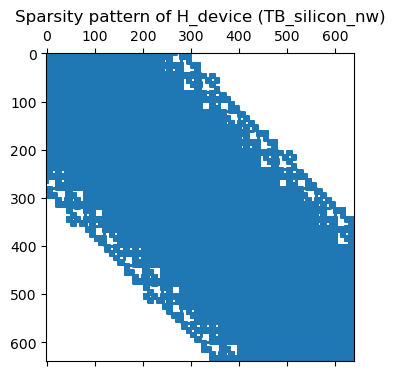

In [134]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Load silicon nanowire TB dataset
_data_dir = Path("../DFT_data/TB_silicon_nw").resolve()

# Core NEGF inputs
energy = np.load(_data_dir / "Energy_grid.npy")
energy_abs_ref = np.load(_data_dir / "Energy_grid_absolute.npy")
sigma_L_ref = np.load(_data_dir / "Sigma_L_stack.npy")
sigma_R_ref = np.load(_data_dir / "Sigma_R_stack.npy")
H_left = np.load(_data_dir / "H_left.npy")
S_left = np.load(_data_dir / "S_left.npy")
H_right = np.load(_data_dir / "H_right.npy")
S_right = np.load(_data_dir / "S_right.npy")
H_device = np.load(_data_dir / "H_device.npy")
S_device = np.load(_data_dir / "S_device.npy")

# Structure metadata requested by you
central_coords_angstrom = np.load(_data_dir / "central_coords_angstrom.npy")
central_elements = np.load(_data_dir / "central_elements.npy")
atom_offsets = np.load(_data_dir / "atom_offsets.npy")

# Optional DOS reference exported by ATK
dos_energy_rel_ref = np.load(_data_dir / "DOS_energies_relative.npy")
dos_total_ref = np.load(_data_dir / "DOS_total.npy")

# Quick sanity checks
print(f"Loaded dataset: {_data_dir.name}")
print(f"H_device shape: {H_device.shape}, S_device shape: {S_device.shape}")
print(f"Central region atoms: {len(central_elements)}")

# Visual check of sparsity
plt.figure(figsize=(5, 4))
plt.spy(H_device, markersize=1)
plt.title("Sparsity pattern of H_device (TB_silicon_nw)")
plt.show()

## determine equilibrium fermi energy

In [135]:
# --- Build electron count + geometry metadata from dataset arrays ---

# Valence model (symbols + atomic numbers)
_valence_by_symbol = {
    "H": 1.0,
    "C": 4.0,
    "Si": 4.0,
}
_valence_by_Z = {
    1: 1.0,
    6: 4.0,
    14: 4.0,
}

elements = np.asarray(central_elements)
if elements.dtype.kind in {"U", "S", "O"}:
    elements_norm = np.array([str(x) for x in elements])
    unique_el, counts_el = np.unique(elements_norm, return_counts=True)
    missing = [el for el in unique_el if el not in _valence_by_symbol]
    if missing:
        raise ValueError(f"Missing valence mapping for element symbols: {missing}")
    N_val = int(round(sum(_valence_by_symbol[el] * int(c) for el, c in zip(unique_el, counts_el))))
    element_summary = dict(zip(unique_el.tolist(), counts_el.tolist()))
else:
    elements_Z = elements.astype(int)
    unique_Z, counts_Z = np.unique(elements_Z, return_counts=True)
    missing = [int(Z) for Z in unique_Z if int(Z) not in _valence_by_Z]
    if missing:
        raise ValueError(f"Missing valence mapping for atomic numbers: {missing}")
    N_val = int(round(sum(_valence_by_Z[int(Z)] * int(c) for Z, c in zip(unique_Z, counts_Z))))
    element_summary = dict(zip(unique_Z.tolist(), counts_Z.tolist()))

# Geometry info from central_coords_angstrom.npy
coord_min = central_coords_angstrom.min(axis=0)
coord_max = central_coords_angstrom.max(axis=0)
span = coord_max - coord_min

N_val = N_val

print("--- TB_silicon_nw metadata ---")
print(f"Elements in central region: {element_summary}")
print(f"Valence electrons (N_val): {N_val}")
print(f"H_device orbitals: {H_device.shape[0]}")
print(f"Central coordinates span [Å]: x={span[0]:.3f}, y={span[1]:.3f}, z={span[2]:.3f}")
print(f"atom_offsets length: {len(atom_offsets)}")

--- TB_silicon_nw metadata ---
Elements in central region: {'H': 64, 'Si': 64}
Valence electrons (N_val): 320
H_device orbitals: 640
Central coordinates span [Å]: x=8.177, y=8.177, z=21.371
atom_offsets length: 65


In [136]:
# Build lead principal-layer blocks once
nL = sigma_L_ref.shape[1]
H00_L = H_device[:nL, :nL]
S00_L = S_device[:nL, :nL]
H01_L = H_device[:nL, nL:2*nL]
H10_L = H_device[nL:2*nL, :nL]
S01_L = S_device[:nL, nL:2*nL]
S10_L = S_device[nL:2*nL, :nL]

H00_R = H_device[-nL:, -nL:]
S00_R = S_device[-nL:, -nL:]
H01_R = H_device[-nL:, -2*nL:-nL]
H10_R = H_device[-2*nL:-nL, -nL:]
S01_R = S_device[-nL:, -2*nL:-nL]
S10_R = S_device[-2*nL:-nL, -nL:]

In [137]:
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
from negf.gf.recursive_greens_functions import _recursive_inverse

_eta = 1e-6
_damp = 1e-6
_tol = 1e-10


# Wide integration window to capture deep valence states
E_grid = np.linspace(-17.0, 2.0, 1201)

def _dos_one(i):
    E = float(E_grid[i])

    sigL = sancho_rubio_iterative_greens_function(
        E, h_l=H01_L, h_0=H00_L, h_r=H10_L,
        s_l=S01_L, s_0=S00_L, s_r=S10_L,
        damp=_damp, nconv=_tol,
    )
    sigR = sancho_rubio_iterative_greens_function(
        E, h_l=H01_R, h_0=H00_R, h_r=H10_R,
        s_l=S01_R, s_0=S00_R, s_r=S10_R,
        damp=_damp, nconv=_tol,
    )

    res = _recursive_inverse(
        E, H_device, sigL, sigR,
        compute_lesser=False,
        overlap_matrix=S_device,
        eta=_eta,
        return_trace=True,
        return_diag=False,
        return_gamma=False,
    )

    return float(-np.imag(res[-1]) / np.pi)

_nproc = 16
_ctx = mp.get_context("fork")
with ProcessPoolExecutor(max_workers=_nproc, mp_context=_ctx) as ex:
    dos_list = list(ex.map(_dos_one, range(len(E_grid)), chunksize=max(1, len(E_grid)//(_nproc*4))))

dos_negf = np.array(dos_list, dtype=float)
print("Done.")

Done.


Ev = -7.959260 eV
Ec = -7.594925 eV
Ef (mid-gap) = -7.777093 eV
chosen deltaN = 2.646e-03


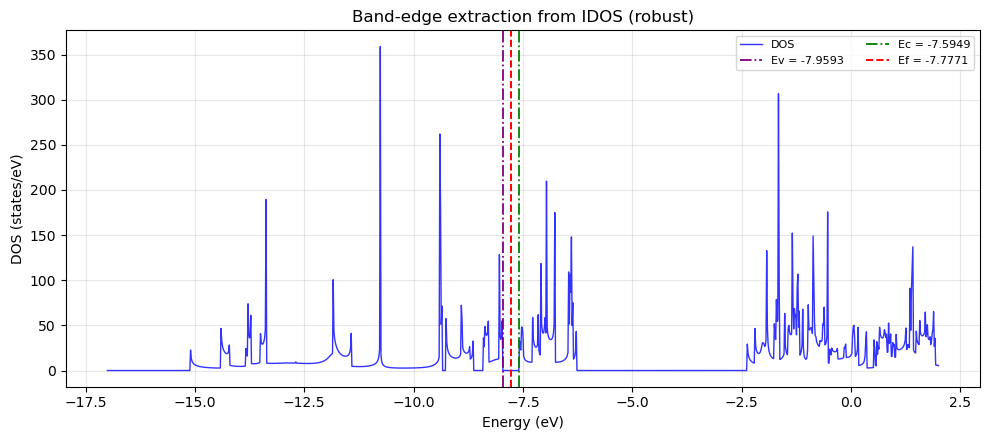

In [138]:
# Band-edge extraction from integrated DOS (IDOS): robust against spiky DOS
E = np.asarray(E_grid, dtype=float)
dos = np.asarray(dos_negf, dtype=float)
n = len(E)

def find_Ec_Ev(E_grid, dos, n=None):
    E = np.asarray(E_grid, dtype=float)
    dos = np.asarray(dos, dtype=float)
    n = len(E) if n is None else int(n)

    # Basic cleanup
    dos_clip = np.maximum(dos, 0.0)
    dE = np.diff(E)
    if np.any(dE <= 0):
        raise ValueError("E_grid must be strictly increasing.")

    # Cumulative trapezoid integral: I(E) = integral DOS dE
    idos = np.zeros(n, dtype=float)
    idos[1:] = np.cumsum(0.5 * (dos_clip[1:] + dos_clip[:-1]) * dE)

    # 1) Coarse gap from low-DOS interior segment
    log_eps = max(1e-18, 1e-12 * float(np.max(dos_clip) + 1e-30))
    log_dos = np.log10(dos_clip + log_eps)
    log_low_thresh = np.percentile(log_dos, 30)
    is_low = log_dos <= log_low_thresh

    segments = []
    in_seg = False
    start = 0
    for i, flag in enumerate(is_low):
        if flag and not in_seg:
            start = i
            in_seg = True
        elif (not flag) and in_seg:
            segments.append((start, i - 1))
            in_seg = False
    if in_seg:
        segments.append((start, n - 1))

    interior = [
        (a, b)
        for (a, b) in segments
        if a > int(0.03 * n) and b < int(0.97 * n) and a > 0 and b < n - 1
    ]
    if not interior:
        raise RuntimeError("No interior low-DOS segment found for gap detection.")

    E_mid = 0.5 * (E[0] + E[-1])
    a_gap, b_gap = min(interior, key=lambda t: abs(0.5 * (E[t[0]] + E[t[1]]) - E_mid))
    Ev_coarse = float(E[a_gap - 1])
    Ec_coarse = float(E[b_gap + 1])
    Ef_seed = 0.5 * (Ev_coarse + Ec_coarse)

    # IDOS plateau reference inside coarse gap
    I_gap = float(np.median(idos[a_gap:b_gap + 1]))

    def _cross_ev_from_deltaN(deltaN):
        # Rightmost E<Ef where I_gap - I(E) >= deltaN
        idx = np.where(E < Ef_seed)[0]
        if len(idx) < 2:
            return np.nan
        F = (I_gap - idos[idx]) - deltaN
        for k in range(len(idx) - 1, 0, -1):
            f0 = F[k - 1]
            f1 = F[k]
            if f0 * f1 <= 0:
                e0 = E[idx[k - 1]]
                e1 = E[idx[k]]
                if abs(f1 - f0) < 1e-20:
                    return float(e1)
                return float(e0 + (0.0 - f0) * (e1 - e0) / (f1 - f0))
        return np.nan

    def _cross_ec_from_deltaN(deltaN):
        # Leftmost E>Ef where I(E) - I_gap >= deltaN
        idx = np.where(E > Ef_seed)[0]
        if len(idx) < 2:
            return np.nan
        F = (idos[idx] - I_gap) - deltaN
        for k in range(1, len(idx)):
            f0 = F[k - 1]
            f1 = F[k]
            if f0 * f1 <= 0:
                e0 = E[idx[k - 1]]
                e1 = E[idx[k]]
                if abs(f1 - f0) < 1e-20:
                    return float(e0)
                return float(e0 + (0.0 - f0) * (e1 - e0) / (f1 - f0))
        return np.nan

    # 2) Scan deltaN and pick the most stable Ev/Ec pair
    idos_span = max(float(idos[-1] - idos[0]), 1e-20)
    deltaN_grid = np.geomspace(1e-6 * idos_span, 2e-3 * idos_span, 25)

    cand = []
    for dN in deltaN_grid:
        Ev_d = _cross_ev_from_deltaN(float(dN))
        Ec_d = _cross_ec_from_deltaN(float(dN))
        if np.isfinite(Ev_d) and np.isfinite(Ec_d) and Ec_d > Ev_d:
            cand.append((float(dN), float(Ev_d), float(Ec_d)))

    if len(cand) < 3:
        Ev = Ev_coarse
        Ec = Ec_coarse
        chosen_deltaN = np.nan
        print("Warning: insufficient IDOS crossing candidates; falling back to coarse edges.")
    else:
        cand = np.array(cand, dtype=float)
        Ev_arr = cand[:, 1]
        Ec_arr = cand[:, 2]

        score = np.full(len(cand), np.inf, dtype=float)
        for i in range(1, len(cand) - 1):
            dEv = abs(Ev_arr[i + 1] - Ev_arr[i - 1])
            dEc = abs(Ec_arr[i + 1] - Ec_arr[i - 1])
            score[i] = dEv + dEc

        i_best = int(np.argmin(score))
        chosen_deltaN = float(cand[i_best, 0])
        Ev = float(cand[i_best, 1])
        Ec = float(cand[i_best, 2])

    return Ec, Ev, chosen_deltaN

Ec, Ev, chosen_deltaN = find_Ec_Ev(E, dos, n)
Ef_negf = 0.5 * (Ec + Ev)

print(f"Ev = {Ev:.6f} eV")
print(f"Ec = {Ec:.6f} eV")
print(f"Ef (mid-gap) = {Ef_negf:.6f} eV")
print(f"chosen deltaN = {chosen_deltaN:.3e}")

plt.figure(figsize=(10, 4.5))
plt.plot(E, dos, "b-", lw=1.0, alpha=0.8, label="DOS")
plt.axvline(Ev, color="purple", ls="-.", lw=1.3, label=f"Ev = {Ev:.4f}")
plt.axvline(Ec, color="green", ls="-.", lw=1.3, label=f"Ec = {Ec:.4f}")
plt.axvline(Ef_negf, color="r", ls="--", lw=1.4, label=f"Ef = {Ef_negf:.4f}")
plt.xlabel("Energy (eV)")
plt.ylabel("DOS (states/eV)")
plt.title("Band-edge extraction from IDOS (robust)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [139]:
delta_E = (Ec - Ev) / 2

# define device

In [140]:
Ef0 = float(Ef_negf) if "Ef_negf" in globals() else -4.317500
Ev0 = float(Ev) if "Ev" in globals() else -5.837500
Ec0 = float(Ec) if "Ec" in globals() else -2.797500

# scaling
V_0 = 0.026          # voltage scale (V)
L_0 = 1.0e-10        # length scale (m), i.e. 1 Å
N_0 = 1e24           # density scale (m^-3)

# doping
Nd_physical_val = 1.0e25  # 1e19 cm^-3 (Source/Drain)
ni_physical_val = 1.0e16
Nd_val = Nd_physical_val / N_0

# constants
q = 1.609e-19
eps_0 = 8.854e-12
poisson_coeff = (q * N_0 * (L_0**2)) / (eps_0 * V_0)

# junction size from channel geometry (central region), in Angstrom
coord_min = central_coords_angstrom.min(axis=0)
coord_max = central_coords_angstrom.max(axis=0)
span = coord_max - coord_min

Lx = float(span[0])
Ly = float(span[1])
Lz = float(span[2])

# normalized dimensions: since L_0 = 1 Å, these are numerically equal to Lx/Ly/Lz in Å
x_dim = Lx
y_dim = Ly
z_dim = Lz

Nx = 100
Ny = 30
Nz = 30

# material property
eps_si_rel = 11.7

# Applied terminal biases (Volts)
V_applied_left = 0.0
V_applied_right = 0.0

# define mesh

In [141]:
from mpi4py import MPI
from dolfinx import mesh
from dolfinx import fem
import ufl
from dolfinx import default_scalar_type
from dolfinx.fem.petsc import LinearProblem
import pyvista
import pyvista as pv
from dolfinx import plot

pyvista.set_jupyter_backend("static")
pyvista.start_xvfb()

# 3D domain (box): [0,0,0] to [x_dim, y_dim, z_dim]
domain = mesh.create_box(
    MPI.COMM_WORLD,
    [[0.0, 0.0, 0.0], [x_dim, y_dim, z_dim]],
    [Nx, Ny, Nz],
    cell_type=mesh.CellType.tetrahedron,
)


/home/nandan_diwan/.conda/envs/negf_env/lib/python3.11/site-packages/pyvista/plotting/utilities/xvfb.py:48: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk-osmesa instead.
  warnings.warn(


In [142]:
V = fem.functionspace(domain, ("Lagrange", 1)) # this is the potential transformation space
Q = fem.functionspace(domain, ("DG", 0)) # this is piece wise 

# translation from FEM grid to atomistic grid

In [143]:
from scipy.spatial import cKDTree
from dolfinx import geometry as dfx_geom


class AtomFEMTranslator:
    """Bi-directional translator between atomistic (NEGF) and FEM (dolfinx) grids.

    Atom → FEM:  Gaussian smearing of per-atom scalar values onto DG0 cell grid.
    FEM  → Atom: Point evaluation of a dolfinx Function at atom positions (pooling).

    Parameters
    ----------
    atom_coords_mesh : (N_atoms, 3) ndarray
        Atom positions in the mesh coordinate frame (origin at [0,0,0]).
    domain : dolfinx.mesh.Mesh
    n_orbitals : int
        Total number of orbitals (H_device.shape[0]).
    orbs_per_atom : int or (N_atoms,) array
        Number of basis orbitals per atom.  Scalar → uniform.
    sigma : float or None
        Gaussian smearing width (Å).  If None, median nearest-neighbour distance.
    """

    def __init__(self, atom_coords_mesh, domain, n_orbitals,
                 orbs_per_atom=None, sigma=None):

        self.coords = np.asarray(atom_coords_mesh, dtype=np.float64)
        self.n_atoms = len(self.coords)
        self.n_orbitals = n_orbitals

        # ---- orbital <-> atom mapping ----
        if orbs_per_atom is None:
            orbs_per_atom = n_orbitals // self.n_atoms
        if np.isscalar(orbs_per_atom):
            orbs_per_atom = np.full(self.n_atoms, int(orbs_per_atom), dtype=int)
        self._orbs_per_atom = np.asarray(orbs_per_atom, dtype=int)
        assert self._orbs_per_atom.sum() == n_orbitals, \
            f"sum(orbs_per_atom)={self._orbs_per_atom.sum()} != n_orbitals={n_orbitals}"

        # cumulative offsets  (length n_atoms + 1)
        self.offsets = np.concatenate(([0], np.cumsum(self._orbs_per_atom)))

        # flat array: orbital index → atom index  (for np.bincount)
        self.orbital_to_atom = np.zeros(n_orbitals, dtype=int)
        for j in range(self.n_atoms):
            self.orbital_to_atom[self.offsets[j]:self.offsets[j + 1]] = j

        # ---- Gaussian sigma ----
        if sigma is None:
            tree = cKDTree(self.coords)
            dd, _ = tree.query(self.coords, k=2)
            sigma = float(np.median(dd[:, 1]))
        self.sigma = sigma

        # ---- cell midpoints (atom → FEM smearing) ----
        _tdim = domain.topology.dim
        _n_cells = domain.topology.index_map(_tdim).size_local
        _cells = np.arange(_n_cells, dtype=np.int32)
        self.cell_mids = mesh.compute_midpoints(domain, _tdim, _cells)
        self.n_cells = _n_cells

        # ---- bounding-box tree (FEM → atom evaluation) ----
        bb = dfx_geom.bb_tree(domain, _tdim)
        candidates = dfx_geom.compute_collisions_points(bb, self.coords)
        colliding = dfx_geom.compute_colliding_cells(
            domain, candidates, self.coords)

        self._atom_cells = np.zeros(self.n_atoms, dtype=np.int32)
        _fallback = 0
        for i in range(self.n_atoms):
            links = colliding.links(i)
            if len(links) > 0:
                self._atom_cells[i] = links[0]
            else:
                dists = np.linalg.norm(
                    self.cell_mids - self.coords[i], axis=1)
                self._atom_cells[i] = np.argmin(dists)
                _fallback += 1

        print(f"AtomFEMTranslator: {self.n_atoms} atoms, "
              f"{self.n_cells} cells, {self.n_orbitals} orbitals "
              f"({self._orbs_per_atom[0]}/atom), sigma = {self.sigma:.3f} Å"
              + (f"  ({_fallback} fallback)" if _fallback else ""))

    # ------------------------------------------------------------------ #
    #  orbital <-> atom aggregation                                        #
    # ------------------------------------------------------------------ #
    def orbitals_to_atoms(self, orbital_vals):
        """Sum orbital-resolved values to per-atom values."""
        return np.bincount(self.orbital_to_atom,
                           weights=np.real(orbital_vals),
                           minlength=self.n_atoms)

    def atoms_to_orbitals(self, atom_vals):
        """Expand per-atom values to the orbital basis (constant within each atom)."""
        return np.asarray(atom_vals, dtype=np.float64)[self.orbital_to_atom]

    # ------------------------------------------------------------------ #
    #  atom → FEM  (Gaussian smearing)                                   #
    # ------------------------------------------------------------------ #
    def atom_to_fem(self, atom_values):
        """Gaussian-smear per-atom values onto DG0 cell midpoints.

        f(r_cell) = \sum_i  w_i v_i  /  \sum w_i
        with  w_i = exp( -|r_cell - r_atom_i|² / 2sigma² ).

        Parameters
        ----------
        atom_values : (N_atoms,)

        Returns
        -------
        cell_values : (n_cells,)
        """
        v = np.asarray(atom_values, dtype=np.float64)
        result = np.zeros(self.n_cells, dtype=np.float64)
        norm   = np.zeros(self.n_cells, dtype=np.float64)
        inv_2s2 = 1.0 / (2.0 * self.sigma ** 2)

        for i in range(self.n_atoms):
            d = self.cell_mids - self.coords[i]
            w = np.exp(-np.sum(d * d, axis=1) * inv_2s2)
            result += w * v[i]
            norm   += w

        norm[norm == 0] = 1.0
        return result / norm

    # ------------------------------------------------------------------ #
    #  FEM → atom  (point evaluation / pooling)                          #
    # ------------------------------------------------------------------ #
    def fem_to_atom(self, fem_func):
        """Evaluate a dolfinx Function at each atom position.

        Parameters
        ----------
        fem_func : dolfinx.fem.Function

        Returns
        -------
        atom_values : (N_atoms,)
        """
        vals = fem_func.eval(self.coords, self._atom_cells)
        return np.asarray(vals, dtype=np.float64).flatten()

    # ------------------------------------------------------------------ #
    #  compound helpers                                                  #
    # ------------------------------------------------------------------ #
    def orbital_to_fem(self, orbital_vals):
        """orbital values → atom sum → Gaussian smear to FEM cells."""
        return self.atom_to_fem(self.orbitals_to_atoms(orbital_vals))

    def fem_to_orbital(self, fem_func):
        """FEM function → atom eval → expand to orbital basis."""
        return self.atoms_to_orbitals(self.fem_to_atom(fem_func))


# ------------------------------------------------------------------ #
#  Instantiate                                                       #
# ------------------------------------------------------------------ #
atom_coords_mesh = central_coords_angstrom - central_coords_angstrom.min(axis=0)

translator = AtomFEMTranslator(
    atom_coords_mesh=atom_coords_mesh,
    domain=domain,
    n_orbitals=H_device.shape[0],      # 640
)

# Preparation

AtomFEMTranslator: 128 atoms, 540000 cells, 640 orbitals (5/atom), sigma = 1.480 Å


### testing

In [144]:
# --- Round-trip tests ---

# 1) orbital <-> atom: constant per-atom value round-trips correctly
dummy_atom = np.arange(translator.n_atoms, dtype=float)
orb = translator.atoms_to_orbitals(dummy_atom)
back = translator.orbitals_to_atoms(orb)
n_orbs_per_atom = translator._orbs_per_atom
assert np.allclose(back, dummy_atom * n_orbs_per_atom), "orbital round-trip failed"
print("✓ orbital ↔ atom round-trip")

# 2) atom → FEM: constant field stays constant after smearing
const_val = 7.0
cell_vals = translator.atom_to_fem(np.full(translator.n_atoms, const_val))
assert np.allclose(cell_vals, const_val, atol=1e-10), \
    f"constant smearing failed: [{cell_vals.min():.6f}, {cell_vals.max():.6f}]"
print(f"✓ atom→FEM constant field  (range [{cell_vals.min():.6f}, {cell_vals.max():.6f}])")

# 3) FEM → atom: linear field f(x,y,z) = z evaluated at atoms
phi_test = fem.Function(V)
phi_test.interpolate(lambda x: x[2])
z_at_atoms = translator.fem_to_atom(phi_test)
err = np.max(np.abs(z_at_atoms - atom_coords_mesh[:, 2]))
print(f"✓ FEM→atom linear field  (max err = {err:.2e})")

# 4) summary
print(f"\n  atoms     = {translator.n_atoms}")
print(f"  orbitals  = {translator.n_orbitals}  ({n_orbs_per_atom[0]}/atom)")
print(f"  FEM cells = {translator.n_cells}")
print(f"  sigma         = {translator.sigma:.3f} Å")


✓ orbital ↔ atom round-trip
✓ atom→FEM constant field  (range [7.000000, 7.000000])
✓ FEM→atom linear field  (max err = 3.55e-15)

  atoms     = 128
  orbitals  = 640  (5/atom)
  FEM cells = 540000
  sigma         = 1.480 Å


# doping

In [145]:
Eg = Ec0 - Ev0 # Ec0 and Ev0 are not shifted yet 
fdim = domain.topology.dim - 1

# left/right on z-min/z-max faces (transport along z)
left_facets = mesh.locate_entities_boundary(
    domain, fdim, lambda x: np.isclose(x[2], 0.0)
)
right_facets = mesh.locate_entities_boundary(
    domain, fdim, lambda x: np.isclose(x[2], z_dim)
)

left_dofs = fem.locate_dofs_topological(V, fdim, left_facets)
right_dofs = fem.locate_dofs_topological(V, fdim, right_facets)


# n-i-n Doping arrays (DG0)
Nd_norm = fem.Function(Q)
Na_norm = fem.Function(Q)

# Cell centers (local cells)
tdim = domain.topology.dim
num_local_cells = domain.topology.index_map(tdim).size_local
all_cells = np.arange(num_local_cells, dtype=np.int32)
mids = mesh.compute_midpoints(domain, tdim, all_cells)
zm = mids[:, 2]

# Define n-i-n regions (Let's make the channel the middle third for this example)
z_source_end = z_dim / 3.0
z_drain_start = 2.0 * z_dim / 3.0

is_source = zm < z_source_end
is_drain = zm > z_drain_start
is_channel = ~(is_source | is_drain) # Intrinsic region

# Fill DG0 arrays (normalized concentrations)
Nd_array = np.zeros_like(Nd_norm.x.array, dtype=default_scalar_type)
Na_array = np.zeros_like(Na_norm.x.array, dtype=default_scalar_type) # Stays 0 for n-i-n

# Apply Donor doping to Source and Drain regions
Nd_array[all_cells[is_source]] = default_scalar_type(Nd_val)
Nd_array[all_cells[is_drain]] = default_scalar_type(Nd_val)
# Intrinsic channel naturally remains 0.0

Nd_norm.x.array[:] = Nd_array
Na_norm.x.array[:] = Na_array

# Net doping for visualization/debug
net_doping = Nd_norm.x.array.real - Na_norm.x.array.real

print("--- BC and n-i-n doping setup (along z) ---")
print(f"left dofs (Dirichlet): {len(left_dofs)}, right dofs (Dirichlet): {len(right_dofs)}")
print(f"Source region: z < {z_source_end:.3f}")
print(f"Drain region: z > {z_drain_start:.3f}")
print(f"Source cells: {np.count_nonzero(is_source)}")
print(f"Channel cells: {np.count_nonzero(is_channel)}")
print(f"Drain cells: {np.count_nonzero(is_drain)}")
print(f"Net doping range: [{net_doping.min():.3e}, {net_doping.max():.3e}]")

--- BC and n-i-n doping setup (along z) ---
left dofs (Dirichlet): 3131, right dofs (Dirichlet): 3131
Source region: z < 7.124
Drain region: z > 14.247
Source cells: 180000
Channel cells: 180000
Drain cells: 180000
Net doping range: [0.000e+00, 1.000e+01]


## new conduction band on leads

--- Lead doping calibration (unshifted leads) ---
Intrinsic reference Ef0: -7.777093 eV
Left lead:  EfL=-7.687837 eV, EcL=-2.433333 eV, EvL=-5.410000 eV
Right lead: EfR=-7.687837 eV, EcR=-2.433333 eV, EvR=-5.410000 eV
For channel Ef=0: Ec_left_eq_eV=5.254503, Ec_right_eq_eV=5.254503
Lead PL atoms: left=16, right=16


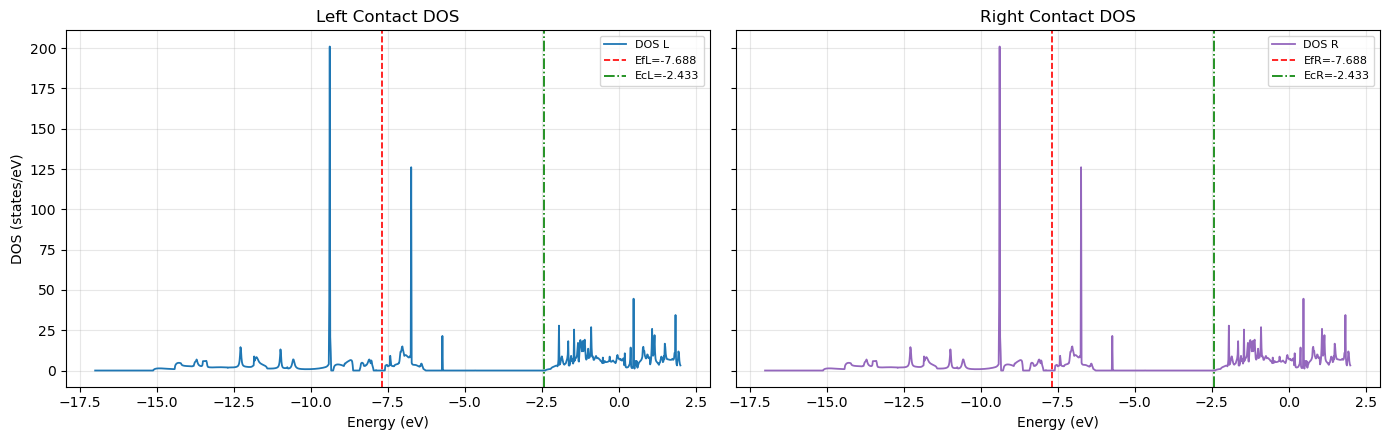

In [146]:
# Lead doping calibration (unshifted lead Hamiltonians) to get Ec shifts at contacts
import numpy as np
import multiprocessing as mp
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from concurrent.futures import ProcessPoolExecutor
import matplotlib.pyplot as plt

eta_lead = 1e-6
kT_eV = V_0
spin_factor = 2.0

E_cal = np.linspace(-17.0, 2.0, 1201)

def _fd(E, mu, kT):
    x = np.clip((E - mu) / max(kT, 1e-12), -200.0, 200.0)
    return 1.0 / (1.0 + np.exp(x))

def _surface_dos_sparse(E, H00, S00, H01, H10, S01, S10):
    sig = sancho_rubio_iterative_greens_function(
        float(E),
        h_l=H01, h_0=H00, h_r=H10,
        s_l=S01, s_0=S00, s_r=S10,
        damp=1e-9j, nconv=1e-12,
    )
    A = ((float(E) + 1j * eta_lead) * S00 - H00 - sig).astype(np.complex128)
    A_sp = sp.csc_matrix(A)
    lu = spla.splu(A_sp)
    X = lu.solve(np.asarray(S00, dtype=np.complex128))  # X = G*S
    return float(-np.imag(np.trace(X)) / np.pi)

def _lead_surface_dos_one(args):
    side, E = args
    if side == "L":
        return _surface_dos_sparse(E, H00_L, S00_L, H01_L, H10_L, S01_L, S10_L)
    return _surface_dos_sparse(E, H00_R, S00_R, H01_R, H10_R, S01_R, S10_R)

def _extract_edges(E, dos):
    E = np.asarray(E, dtype=float)
    dos = np.asarray(dos, dtype=float)
    n = len(E)

    win_gap = 21
    dos_gap = np.convolve(dos, np.ones(win_gap, dtype=float) / win_gap, mode="same")
    th_low = min(np.percentile(dos_gap, 25), 0.05 * float(np.max(dos_gap) + 1e-30))
    is_low = dos_gap <= th_low

    segments = []
    in_seg = False
    start = 0
    for i, flag in enumerate(is_low):
        if flag and not in_seg:
            start = i
            in_seg = True
        elif (not flag) and in_seg:
            segments.append((start, i - 1))
            in_seg = False
    if in_seg:
        segments.append((start, n - 1))

    interior = [(a, b) for (a, b) in segments if a > int(0.03 * n) and b < int(0.97 * n) and a > 0 and b < n - 1]
    if not interior:
        return np.nan, np.nan

    a, b = max(interior, key=lambda t: t[1] - t[0])
    Ev_coarse = float(E[a - 1])
    Ec_coarse = float(E[b + 1])
    Ef_mid = 0.5 * (Ev_coarse + Ec_coarse)

    win_edge = 41
    dos_edge = np.convolve(dos, np.ones(win_edge, dtype=float) / win_edge, mode="same")
    iF = int(np.argmin(np.abs(E - Ef_mid)))
    iL = max(0, iF - 80)
    iR = min(n, iF + 81)
    gap_floor = float(np.percentile(dos_edge[iL:iR], 10))
    dos_hi = float(np.percentile(dos_edge, 85))
    edge_thresh = gap_floor + 0.06 * max(dos_hi - gap_floor, 1e-30)
    hold = 6

    Ec_ref = np.nan
    for i in range(iF + 1, n - hold):
        if np.all(dos_edge[i:i + hold] > edge_thresh):
            Ec_ref = float(E[i])
            break

    Ev_ref = np.nan
    for i in range(iF - 1, hold - 1, -1):
        if np.all(dos_edge[i - hold + 1:i + 1] > edge_thresh):
            Ev_ref = float(E[i])
            break

    Ec_val = Ec_ref if np.isfinite(Ec_ref) else Ec_coarse
    Ev_val = Ev_ref if np.isfinite(Ev_ref) else Ev_coarse
    return Ev_val, Ec_val

nproc = 16
ctx = mp.get_context("fork")
with ProcessPoolExecutor(max_workers=nproc, mp_context=ctx) as ex:
    dos_lead_L = np.array(
        list(ex.map(_lead_surface_dos_one, (("L", float(E)) for E in E_cal), chunksize=max(1, len(E_cal)//(nproc*4)))),
        dtype=float,
    )
with ProcessPoolExecutor(max_workers=nproc, mp_context=ctx) as ex:
    dos_lead_R = np.array(
        list(ex.map(_lead_surface_dos_one, (("R", float(E)) for E in E_cal), chunksize=max(1, len(E_cal)//(nproc*4)))),
        dtype=float,
    )

EvL, EcL = _extract_edges(E_cal, dos_lead_L)
EvR, EcR = _extract_edges(E_cal, dos_lead_R)

def _N_of_mu(mu, E, dos, kT):
    occ = _fd(E, mu, kT)
    return float(spin_factor * np.trapezoid(dos * occ, E))

# Unshifted lead Hamiltonian basis: intrinsic reference at Ef0
mu_intr = float(Ef0)
N_intr_L = _N_of_mu(mu_intr, E_cal, dos_lead_L, kT_eV)
N_intr_R = _N_of_mu(mu_intr, E_cal, dos_lead_R, kT_eV)

# Convert physical doping target to extra electrons in one lead principal-layer volume
n_atoms_total = max(int(len(atom_offsets) - 1), 1)
atom_vol_m3 = (x_dim * L_0) * (y_dim * L_0) * (z_dim * L_0) / n_atoms_total
offsets = np.asarray(atom_offsets, dtype=int)
n_atoms_left_pl = int(np.count_nonzero(offsets[1:] <= nL))
n_atoms_right_pl = int(np.count_nonzero((H_device.shape[0] - offsets[:-1]) <= nL))
n_atoms_left_pl = max(n_atoms_left_pl, 1)
n_atoms_right_pl = max(n_atoms_right_pl, 1)

V_left_pl = n_atoms_left_pl * atom_vol_m3
V_right_pl = n_atoms_right_pl * atom_vol_m3

Nd_left_phys = float(Nd_physical_val)
Nd_right_phys = float(Nd_physical_val)

dN_target_L = Nd_left_phys * V_left_pl
dN_target_R = Nd_right_phys * V_right_pl
N_target_L = N_intr_L + dN_target_L
N_target_R = N_intr_R + dN_target_R

def _solve_mu_for_target(N_target, E, dos, mu0, kT):
    def f(mu):
        return _N_of_mu(mu, E, dos, kT) - N_target

    a, b = mu0 - 2.0, mu0 + 2.0
    fa, fb = f(a), f(b)
    expand = 0
    while fa * fb > 0 and expand < 8:
        a -= 1.0
        b += 1.0
        fa, fb = f(a), f(b)
        expand += 1

    if fa * fb > 0:
        mu_scan = np.linspace(a, b, 801)
        vals = np.array([abs(f(m)) for m in mu_scan])
        return float(mu_scan[np.argmin(vals)])

    for _ in range(80):
        m = 0.5 * (a + b)
        fm = f(m)
        if abs(fm) < 1e-10:
            return float(m)
        if fa * fm <= 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return float(0.5 * (a + b))

# Doped lead Fermi levels in unshifted basis
EfL = _solve_mu_for_target(N_target_L, E_cal, dos_lead_L, mu_intr, kT_eV)
EfR = _solve_mu_for_target(N_target_R, E_cal, dos_lead_R, mu_intr, kT_eV)

# Backward-compatible aliases
mu_doped_L = EfL
mu_doped_R = EfR

# Channel Ef reference is 0 -> effective Ec BC references are (Ec - Ef)
Ec_left_eq_eV = float(EcL - EfL)
Ec_right_eq_eV = float(EcR - EfR)
Ev_left_eq_eV = float(EvL - EfL)
Ev_right_eq_eV = float(EvR - EfR)

print("--- Lead doping calibration (unshifted leads) ---")
print(f"Intrinsic reference Ef0: {mu_intr:.6f} eV")
print(f"Left lead:  EfL={EfL:.6f} eV, EcL={EcL:.6f} eV, EvL={EvL:.6f} eV")
print(f"Right lead: EfR={EfR:.6f} eV, EcR={EcR:.6f} eV, EvR={EvR:.6f} eV")
print(f"For channel Ef=0: Ec_left_eq_eV={Ec_left_eq_eV:.6f}, Ec_right_eq_eV={Ec_right_eq_eV:.6f}")
print(f"Lead PL atoms: left={n_atoms_left_pl}, right={n_atoms_right_pl}")

# Plot DOS of left and right contacts with extracted Ef/Ec
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
axes[0].plot(E_cal, dos_lead_L, color="tab:blue", lw=1.3, label="DOS L")
axes[0].axvline(EfL, color="red", ls="--", lw=1.2, label=f"EfL={EfL:.3f}")
axes[0].axvline(EcL, color="green", ls="-.", lw=1.2, label=f"EcL={EcL:.3f}")
axes[0].set_title("Left Contact DOS")
axes[0].set_xlabel("Energy (eV)")
axes[0].set_ylabel("DOS (states/eV)")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(E_cal, dos_lead_R, color="tab:purple", lw=1.3, label="DOS R")
axes[1].axvline(EfR, color="red", ls="--", lw=1.2, label=f"EfR={EfR:.3f}")
axes[1].axvline(EcR, color="green", ls="-.", lw=1.2, label=f"EcR={EcR:.3f}")
axes[1].set_title("Right Contact DOS")
axes[1].set_xlabel("Energy (eV)")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [147]:
# Dirichlet BC from doped-lead conduction-band targets at contacts
Ec_left_ref = float(Ec_left_eq_eV) if "Ec_left_eq_eV" in globals() else float(Ec0)
Ec_right_ref = float(Ec_right_eq_eV) if "Ec_right_eq_eV" in globals() else float(Ec0)

Ec_left_bc_eV = V_applied_left
Ec_right_bc_eV = V_applied_right
psi_left_norm = Ec_left_bc_eV / V_0
psi_right_norm = Ec_right_bc_eV / V_0

# 1. DIRICHLET BC AT SOURCE (Left)
bc_left = fem.dirichletbc(default_scalar_type(psi_left_norm), left_dofs, V)
bc_right = fem.dirichletbc(default_scalar_type(psi_right_norm), right_dofs, V)

# 2. DIRICHLET BC AT DRAIN (Right)
bcs = [bc_left, bc_right]

print("--- Contact BC from doped-lead Ec ---")
print(f"Ec_left_ref={Ec_left_ref:.6f} eV, Ec_right_ref={Ec_right_ref:.6f} eV")
print(f"Ec_left_bc={Ec_left_bc_eV:.6f} eV, Ec_right_bc={Ec_right_bc_eV:.6f} eV")
print(f"psi_left_norm={psi_left_norm:.6f}, psi_right_norm={psi_right_norm:.6f}")

--- Contact BC from doped-lead Ec ---
Ec_left_ref=5.254503 eV, Ec_right_ref=5.254503 eV
Ec_left_bc=0.000000 eV, Ec_right_bc=0.000000 eV
psi_left_norm=0.000000, psi_right_norm=0.000000


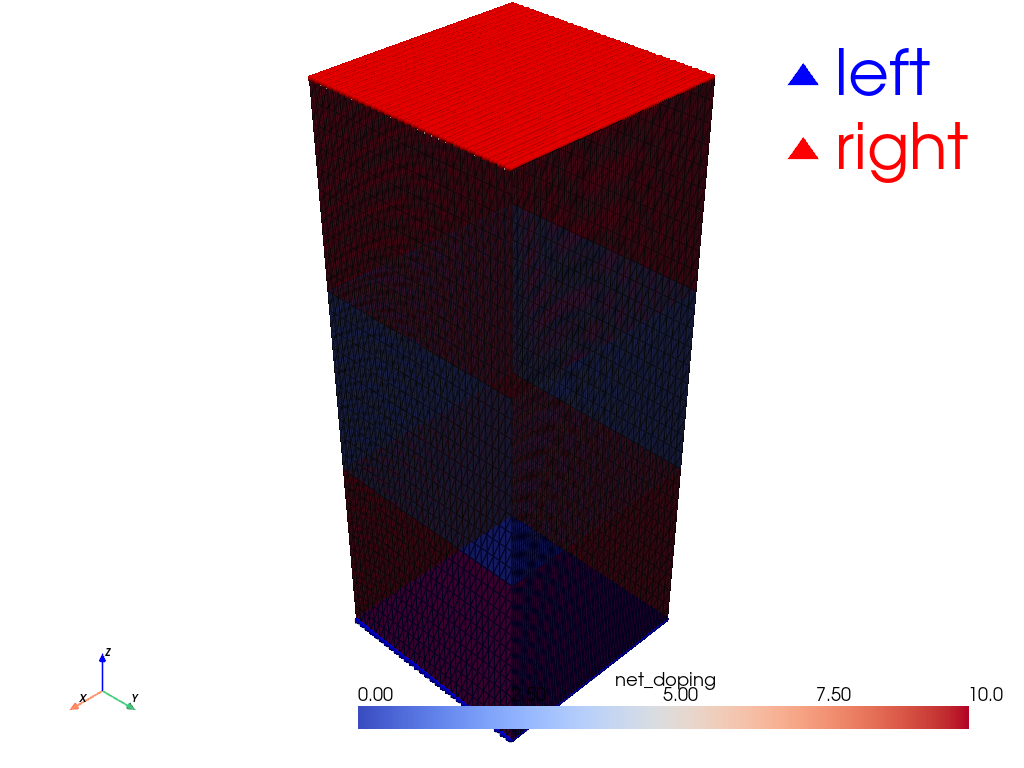

In [148]:
# Minimal visualization: mesh + net doping + BC markers
import pyvista as pv
from dolfinx import plot

# Build VTK grid from mesh topology
topo, cell_types, geom = plot.vtk_mesh(domain, domain.topology.dim)
grid = pv.UnstructuredGrid(topo, cell_types, geom)

# Attach cell-wise net doping (trim if needed)
grid.cell_data["net_doping"] = np.asarray(net_doping[: grid.n_cells], dtype=float)

# Boundary facet midpoints for markers (z-faces)
left_mid = mesh.compute_midpoints(domain, fdim, left_facets)
right_mid = mesh.compute_midpoints(domain, fdim, right_facets)

p = pv.Plotter()
p.add_mesh(grid, scalars="net_doping", show_edges=True, cmap="coolwarm", opacity=0.85)
p.add_points(left_mid, color="blue", point_size=7, render_points_as_spheres=True, label="left")
p.add_points(right_mid, color="red", point_size=7, render_points_as_spheres=True, label="right")
p.add_legend()
p.show_axes()
p.show()

# Solver

## initial poisson solve

In [149]:
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from dolfinx import geometry as dfx_geom_solver

Nc = 2.8e25 * (2.0 / np.sqrt(np.pi))   # m^-3
Nv = 1.04e25 * (2.0 / np.sqrt(np.pi))  # m^-3
kbT = V_0  # 0.026 eV at 300 K

Ec_ref = Ec0 - Ef0
Ev_ref = Ev0 - Ef0 

def _FD_half(x):
    """Fermi-Dirac integral of order 1/2.
    Ref: http://dx.doi.org/10.1063/1.4825209
    """
    v = x**4 + 50 + 33.6 * x * (1 - 0.68 * np.exp(-0.17 * (x + 1)**2))
    return 1.0 / (np.exp(-x) + (3.0 * np.pi**0.5 / 4.0) * v**(-3.0 / 8.0))

def get_semiclassical_charge(psi_norm, Nd_phys, Na_phys):
    """Compute normalized charge density from normalized potential ψ = φ/V₀.

    Parameters
    ----------
    psi_norm : float or array  –  φ / V₀ (dimensionless)
    Nd_phys, Na_phys : float or array  –  physical doping (m⁻³)

    Returns
    -------
    rho_norm : (p - n + Nd - Na) / N₀
    n_phys   : electron concentration (m⁻³)
    p_phys   : hole concentration (m⁻³)
    """
    psi_eV = psi_norm * V_0

    # Shifted band edges (Ef = 0)
    Ec_eff = Ec_ref - psi_eV
    Ev_eff = Ev_ref - psi_eV

    # Reduced Fermi energies
    eta_e = -Ec_eff / kbT        # (Ef − Ec_eff) / kT
    eta_h =  Ev_eff / kbT        # (Ev_eff − Ef) / kT

    n = Nc * _FD_half(eta_e)
    p = Nv * _FD_half(eta_h)

    rho_norm = (p - n + Nd_phys - Na_phys) / N_0
    return rho_norm, n, p


In [150]:

bcs_poisson = [bc_left, bc_right]

eps_rel = fem.Function(Q)
eps_rel.x.array[:] = eps_si_rel

u_psi = ufl.TrialFunction(V)
v_psi = ufl.TestFunction(V)

a_poisson = ufl.inner(eps_rel * ufl.grad(u_psi), ufl.grad(v_psi)) * ufl.dx
L_poisson = fem.Constant(domain, default_scalar_type(0.0)) * v_psi * ufl.dx

problem_init = LinearProblem(
    a_poisson, L_poisson, bcs=bcs_poisson,
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
    petsc_options_prefix="laplace_initial_presolve",
)
phi_init = problem_init.solve()
phi_init.name = "psi_laplace"

print(f"Laplace solve done.  ψ range: [{phi_init.x.array.min():.4f}, {phi_init.x.array.max():.4f}]")
print(f"Potential range: [{phi_init.x.array.min()*V_0:.4f}, {phi_init.x.array.max()*V_0:.4f}] V")

Laplace solve done.  ψ range: [0.0000, 0.0000]
Potential range: [0.0000, 0.0000] V


## first NEGF iteration

In [151]:
# First NEGF Hamiltonian update: piecewise Ec(z) predictor, then H = H + (Ec - phi) in channel-Ef reference
phi_atom = translator.fem_to_atom(phi_init)
phi_orb = translator.atoms_to_orbitals(phi_atom)
phi_orb_eV = phi_orb * V_0

# Contact-calibrated Ec references (already in channel Ef=0 reference)
Ec_left_ref = float(Ec_left_eq_eV) if "Ec_left_eq_eV" in globals() else float(Ec0 - Ef0)
Ec_right_ref = float(Ec_right_eq_eV) if "Ec_right_eq_eV" in globals() else float(Ec0 - Ef0)
Ec_intr_ref = float(Ec0 - Ef0)

# Build orbital z-coordinates from atom coordinates + offsets
atom_z = np.asarray(atom_coords_mesh[:, 2], dtype=float)
orb_z = np.zeros(H_device.shape[0], dtype=float)

# Prefer translator offsets (length n_atoms+1); fallback to atom_offsets
offsets_use = np.asarray(translator.offsets if hasattr(translator, "offsets") else atom_offsets, dtype=int)
n_map = min(len(atom_z), max(len(offsets_use) - 1, 0))
for a in range(n_map):
    i0 = int(offsets_use[a])
    i1 = int(offsets_use[a + 1])
    orb_z[i0:i1] = atom_z[a]

# Use same source/channel/drain cuts as doping definition
z_src = float(z_source_end) if "z_source_end" in globals() else float(np.min(orb_z) + (np.max(orb_z) - np.min(orb_z)) / 3.0)
z_drn = float(z_drain_start) if "z_drain_start" in globals() else float(np.min(orb_z) + 2.0 * (np.max(orb_z) - np.min(orb_z)) / 3.0)

is_src_orb = orb_z < z_src
is_drn_orb = orb_z > z_drn
is_chn_orb = ~(is_src_orb | is_drn_orb)

# Piecewise Ec predictor: flat in intrinsic channel; contact values in doped leads
Ec_orb_eV = np.full(H_device.shape[0], Ec_intr_ref, dtype=float)
Ec_orb_eV[is_src_orb] = Ec_left_ref
Ec_orb_eV[is_drn_orb] = Ec_right_ref

# Potential-energy term V(r) = -phi(r) + (Ec(r) - Ei(r)); taking Ei(r)=0 in channel-Ef reference
include_Ei_offset = False
Ei_orb_eV = np.zeros_like(Ec_orb_eV)
if include_Ei_offset and "Ef0" in globals():
    Ei_orb_eV[:] = float(Ef0)

V_orb_eV = -phi_orb_eV + delta_E #+ (Ec_orb_eV - Ei_orb_eV)

H_device_biased = np.array(H_device, copy=True)
diag_idx = np.diag_indices(H_device_biased.shape[0])
H_device_biased[diag_idx] = H_device[diag_idx] + V_orb_eV

print("--- First-iteration Hamiltonian update (piecewise Ec predictor) ---")
print(f"Ec_left_ref={Ec_left_ref:.6f} eV, Ec_intr_ref={Ec_intr_ref:.6f} eV, Ec_right_ref={Ec_right_ref:.6f} eV")
print(f"mapped atoms to orbitals with n_map={n_map}, offsets_len={len(offsets_use)}")
print(f"orbital region counts: source={np.count_nonzero(is_src_orb)}, channel={np.count_nonzero(is_chn_orb)}, drain={np.count_nonzero(is_drn_orb)}")
print(f"Ec_orb_eV range: [{Ec_orb_eV.min():.4e}, {Ec_orb_eV.max():.4e}]")
print(f"phi_orb_eV range: [{phi_orb_eV.min():.4e}, {phi_orb_eV.max():.4e}]")
print(f"V_orb_eV range: [{V_orb_eV.min():.4e}, {V_orb_eV.max():.4e}]")
print(f"H_device_biased ready: shape={H_device_biased.shape}, dtype={H_device_biased.dtype}")

--- First-iteration Hamiltonian update (piecewise Ec predictor) ---
Ec_left_ref=5.254503 eV, Ec_intr_ref=0.182168 eV, Ec_right_ref=5.254503 eV
mapped atoms to orbitals with n_map=128, offsets_len=129
orbital region counts: source=210, channel=220, drain=210
Ec_orb_eV range: [1.8217e-01, 5.2545e+00]
phi_orb_eV range: [0.0000e+00, 0.0000e+00]
V_orb_eV range: [1.8217e-01, 1.8217e-01]
H_device_biased ready: shape=(640, 640), dtype=complex128


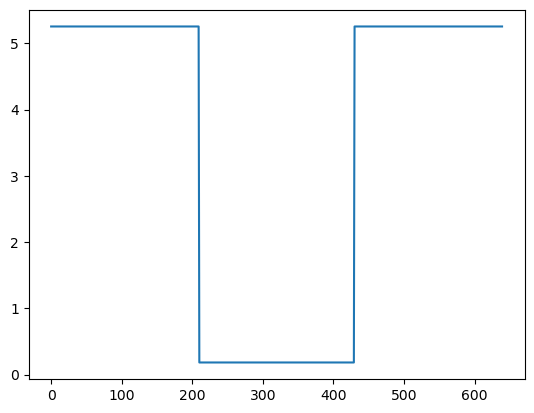

In [152]:
plt.plot(-phi_orb_eV + (Ec_orb_eV - Ei_orb_eV))

In [153]:
# Precompute Sancho-Rubio self-energies on real-energy grid (and optional contour grid)
import os
from concurrent.futures import ProcessPoolExecutor

_eta = 1e-2
_damp = 1e-9j
_tol = 1e-12

mu_left =  float(V_applied_left)
mu_right = float(V_applied_right)
E_grid = np.linspace(min(V_applied_left,V_applied_right), max(V_applied_left,V_applied_right) + 6, 501)
def _sigma_for_energy(args):
    i, E = args
    E = float(E)
    sigL = sancho_rubio_iterative_greens_function(
        E - mu_left,
        h_l=H01_L, h_0=H00_L, h_r=H10_L,
        s_l=S01_L, s_0=S00_L, s_r=S10_L,
        damp=_damp, nconv=_tol,
    )
    sigR = sancho_rubio_iterative_greens_function(
        E - mu_right,
        h_l=H01_R, h_0=H00_R, h_r=H10_R,
        s_l=S01_R, s_0=S00_R, s_r=S10_R,
        damp=_damp, nconv=_tol,
    )
    return i, sigL, sigR

nE = len(E_grid)
sigma_L_cache = [None] * nE
sigma_R_cache = [None] * nE

max_workers = min(max(1, (os.cpu_count() or 1) - 1), nE)
try:
    with ProcessPoolExecutor(max_workers=max_workers) as pool:
        for i, sigL, sigR in pool.map(_sigma_for_energy, list(enumerate(E_grid))):
            sigma_L_cache[i] = sigL
            sigma_R_cache[i] = sigR
except Exception as exc:
    print(f"Parallel sigma precompute fallback to serial due to: {exc}")
    for i, E in enumerate(E_grid):
        _, sigL, sigR = _sigma_for_energy((i, E))
        sigma_L_cache[i] = sigL
        sigma_R_cache[i] = sigR

print(f"Sigma cache ready on real grid: {nE} energies")

Sigma cache ready on real grid: 501 energies


In [ ]:
# Charge density from cached self-energies: split into equilibrium + nonequilibrium
import os
from concurrent.futures import ProcessPoolExecutor
import negf.gf.recursive_greens_functions as rgf

kbT_eff = 0.025851999786435
mu_eq = mu_left  # left lead as equilibrium reference
print(f"C++ recursive available: {rgf._cpp_recursive is not None}")

def _fd(E, mu, kT):
    x = (E - mu) / max(kT, 1e-12)
    x = np.clip(x, -200.0, 200.0)
    return 1.0 / (1.0 + np.exp(x))

def     _charge_contrib(i):
    from negf.gf.recursive_greens_functions import _recursive_inverse
    E = float(E_grid[i])
    sigL = sigma_L_cache[i]
    sigR = sigma_R_cache[i]

    fL = _fd(E, mu_left, kbT_eff)
    fR = _fd(E, mu_right, kbT_eff)
    fEq = _fd(E, mu_eq, kbT_eff)

    out_tot = _recursive_inverse(
        E,
        H_device_biased,
        sigL,
        sigR,
        compute_lesser=True,
        occ_left=fL,
        occ_right=fR,
        overlap_matrix=S_device,
        eta=_eta,
        return_trace=False,
        return_diag=True,
        return_gamma=True,
    )
    g_less_tot = np.asarray(out_tot[1])

    out_eq = _recursive_inverse(
        E,
        H_device_biased,
        sigL,
        sigR,
        compute_lesser=True,
        occ_left=fEq,
        occ_right=fEq,
        overlap_matrix=S_device,
        eta=_eta,
        return_trace=False,
        return_diag=True,
        return_gamma=True,
    )
    g_less_eq = np.asarray(out_eq[1])

    pref = 1.0 / (2.0 * np.pi)
    nE_tot = np.real(g_less_tot) * pref
    nE_eq = np.real(g_less_eq) * pref
    nE_tot = -np.imag(g_less_tot) * pref
    nE_eq = -np.imag(g_less_eq) * pref
dE = np.gradient(np.asarray(E_grid, dtype=float))
n_orb = H_device_biased.shape[0]
rho_eq_orb = np.zeros(n_orb, dtype=float)
rho_neq_orb = np.zeros(n_orb, dtype=float)

max_workers = min(max(1, (os.cpu_count() or 1) - 1), len(E_grid))
try:
    with ProcessPoolExecutor(max_workers=max_workers) as pool:
        for i, nE_eq, nE_neq in pool.map(_charge_contrib, range(len(E_grid))):
            w = dE[i]
            rho_eq_orb += nE_eq * w
            rho_neq_orb += nE_neq * w
except Exception as exc:
    print(f"Parallel charge integration fallback to serial due to: {exc}")
    for i in range(len(E_grid)):
        _, nE_eq, nE_neq = _charge_contrib(i)
        w = dE[i]
        rho_eq_orb += nE_eq * w
        rho_neq_orb += nE_neq * w

rho_tot_orb = rho_eq_orb + rho_neq_orb

rho_eq_atom = translator.orbitals_to_atoms(rho_eq_orb)
rho_neq_atom = translator.orbitals_to_atoms(rho_neq_orb)
rho_tot_atom = translator.orbitals_to_atoms(rho_tot_orb)

print("Charge integration complete")
print(f"rho_eq_atom  range: [{rho_eq_atom.min():.4e}, {rho_eq_atom.max():.4e}]")
print(f"rho_neq_atom range: [{rho_neq_atom.min():.4e}, {rho_neq_atom.max():.4e}]")
print(f"rho_tot_atom range: [{rho_tot_atom.min():.4e}, {rho_tot_atom.max():.4e}]")

C++ recursive available: False


Parallel charge integration fallback to serial due to: cannot unpack non-iterable NoneType object


TypeError: cannot unpack non-iterable NoneType object

Mapped first-run charge to FEM grid
FEM charge range: [1.8139e-03, 3.3408e-03]


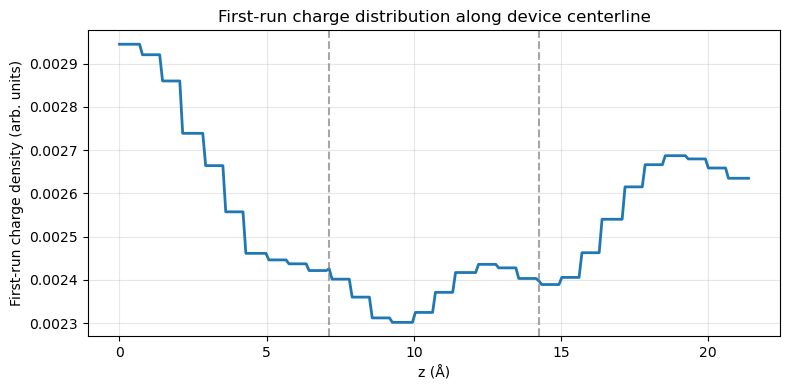

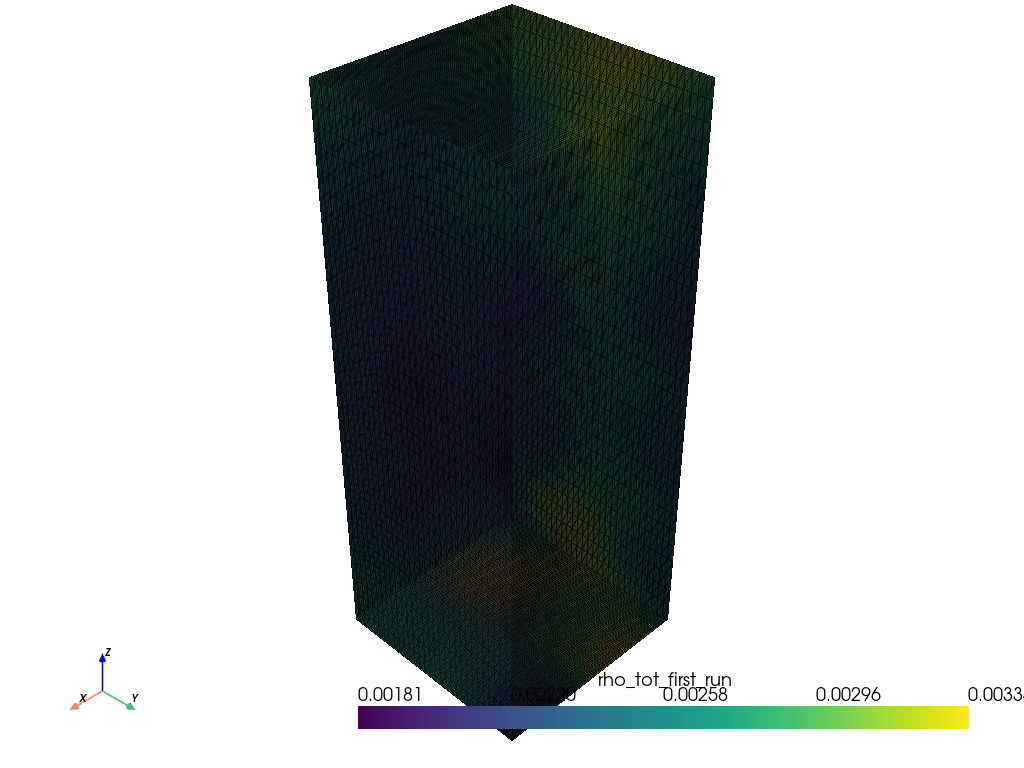

In [ ]:
# Map first-run atomistic charge to FEM grid and visualize through the device
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from dolfinx import plot as dfx_plot

# 1) atom -> FEM (DG0 cell values)
rho_tot_fem_cells = translator.atom_to_fem(rho_tot_atom)

rho_tot_fem = fem.Function(Q)
rho_tot_fem.name = "rho_tot_first_run"
rho_tot_fem.x.array[:] = np.asarray(rho_tot_fem_cells[:len(rho_tot_fem.x.array)], dtype=default_scalar_type)

print("Mapped first-run charge to FEM grid")
print(f"FEM charge range: [{rho_tot_fem.x.array.min():.4e}, {rho_tot_fem.x.array.max():.4e}]")

# 2) 1D profile through device center (z-direction)
x_mid, y_mid = x_dim / 2.0, y_dim / 2.0
z_pts = np.linspace(0.0, z_dim, 220)
probe_pts = np.column_stack([
    np.full_like(z_pts, x_mid),
    np.full_like(z_pts, y_mid),
    z_pts,
])

bb = dfx_geom_solver.bb_tree(domain, domain.topology.dim)
cell_cands = dfx_geom_solver.compute_collisions_points(bb, probe_pts)
colliding = dfx_geom_solver.compute_colliding_cells(domain, cell_cands, probe_pts)

pts_ok, cells_ok = [], []
for i in range(len(probe_pts)):
    links = colliding.links(i)
    if len(links) > 0:
        pts_ok.append(probe_pts[i])
        cells_ok.append(links[0])

pts_ok = np.array(pts_ok)
rho_line = rho_tot_fem.eval(pts_ok, cells_ok).flatten()
z_line = pts_ok[:, 2]

plt.figure(figsize=(8, 4))
plt.plot(z_line, rho_line, lw=2)
plt.axvline(z_source_end, color="gray", ls="--", alpha=0.7)
plt.axvline(z_drain_start, color="gray", ls="--", alpha=0.7)
plt.xlabel("z (Å)")
plt.ylabel("First-run charge density (arb. units)")
plt.title("First-run charge distribution along device centerline")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3) 3D FEM visualization
topo, cell_types, geom = dfx_plot.vtk_mesh(domain, domain.topology.dim)
grid_rho = pv.UnstructuredGrid(topo, cell_types, geom)
grid_rho.cell_data["rho_tot_first_run"] = np.asarray(rho_tot_fem.x.array[: grid_rho.n_cells], dtype=float)

p = pv.Plotter()
p.add_mesh(grid_rho, scalars="rho_tot_first_run", show_edges=True, cmap="viridis", opacity=0.9)
p.add_axes()
p.show()

In [ ]:
Ec_orb_eV - Ei_orb_eV

array([5.25450342, 5.25450342, 5.25450342, 5.25450342, 5.25450342,
       5.25450342, 5.25450342, 5.25450342, 5.25450342, 5.25450342,
       5.25450342, 5.25450342, 5.25450342, 5.25450342, 5.25450342,
       5.25450342, 5.25450342, 5.25450342, 5.25450342, 5.25450342,
       5.25450342, 5.25450342, 5.25450342, 5.25450342, 5.25450342,
       5.25450342, 5.25450342, 5.25450342, 5.25450342, 5.25450342,
       5.25450342, 5.25450342, 5.25450342, 5.25450342, 5.25450342,
       5.25450342, 5.25450342, 5.25450342, 5.25450342, 5.25450342,
       5.25450342, 5.25450342, 5.25450342, 5.25450342, 5.25450342,
       5.25450342, 5.25450342, 5.25450342, 5.25450342, 5.25450342,
       5.25450342, 5.25450342, 5.25450342, 5.25450342, 5.25450342,
       5.25450342, 5.25450342, 5.25450342, 5.25450342, 5.25450342,
       5.25450342, 5.25450342, 5.25450342, 5.25450342, 5.25450342,
       5.25450342, 5.25450342, 5.25450342, 5.25450342, 5.25450342,
       5.25450342, 5.25450342, 5.25450342, 5.25450342, 5.25450

## Full gummel solve

In [ ]:
# NEGF-Poisson Gummel loop (Hamiltonian shift uses phi + Ec + optional Ef0(Ei))
import numpy as np
import os
from concurrent.futures import ProcessPoolExecutor
import negf.gf.recursive_greens_functions as rgf
from dolfinx.fem.petsc import LinearProblem

# ---- user-tunable controls ----
gummel_max_iter = 800
gummel_tol_phi = 1e-4
mix_phi = 0.25          # slow update
max_delta_phi = 0.25    # clamp in normalized units
_eta_loop = 1e-2


light_mode = False
light_energy_stride = 1
light_max_workers = 20
light_max_iter = 20
light_skip_fd_jacobian = True

rgf._cpp_recursive = None

def _fd_loop(E, mu, kT):
    x = (E - mu) / max(kT, 1e-12)
    x = np.clip(x, -200.0, 200.0)
    return 1.0 / (1.0 + np.exp(x))

# initial guess to Poisson is old phi
phi_gummel = fem.Function(V)

phi_gummel.x.array[:] = phi_init.x.array.copy()

rho_negf_fem = fem.Function(Q)
drho_negf_fem = fem.Function(Q)

# finite-difference sensitivity step for d(rho)/d(phi) in Gummel linearization
dphi_fd = 0.02

box_vol_m3 = (x_dim * L_0) * (y_dim * L_0) * (z_dim * L_0)
atom_vol_m3 = box_vol_m3 / max(int(translator.n_atoms), 1)
atom_norm_scale = atom_vol_m3 * N_0
rho_fixed_cells_norm = np.asarray(
    (Nd_norm.x.array.real - Na_norm.x.array.real)[:len(rho_negf_fem.x.array)],
    dtype=float,
)

# --- Fixed Ec(z) profile for the whole Gummel loop (piecewise source/channel/drain) ---
Ec_left_ref_loop = float(Ec_left_eq_eV) if "Ec_left_eq_eV" in globals() else float(Ec0 - Ef0)
Ec_right_ref_loop = float(Ec_right_eq_eV) if "Ec_right_eq_eV" in globals() else float(Ec0 - Ef0)
Ec_intr_ref_loop = float(Ec0 - Ef0)

atom_z_loop = np.asarray(atom_coords_mesh[:, 2], dtype=float)
orb_z_loop = np.zeros(H_device.shape[0], dtype=float)
offsets_use_loop = np.asarray(translator.offsets if hasattr(translator, "offsets") else atom_offsets, dtype=int)
n_map_loop = min(len(atom_z_loop), max(len(offsets_use_loop) - 1, 0))
for a in range(n_map_loop):
    i0 = int(offsets_use_loop[a])
    i1 = int(offsets_use_loop[a + 1])
    orb_z_loop[i0:i1] = atom_z_loop[a]

z_src_loop = float(z_source_end) if "z_source_end" in globals() else float(np.min(orb_z_loop) + (np.max(orb_z_loop) - np.min(orb_z_loop)) / 3.0)
z_drn_loop = float(z_drain_start) if "z_drain_start" in globals() else float(np.min(orb_z_loop) + 2.0 * (np.max(orb_z_loop) - np.min(orb_z_loop)) / 3.0)

is_src_orb_loop = orb_z_loop < z_src_loop
is_drn_orb_loop = orb_z_loop > z_drn_loop
is_chn_orb_loop = ~(is_src_orb_loop | is_drn_orb_loop)

Ec_orb_loop_eV = np.full(H_device.shape[0], Ec_intr_ref_loop, dtype=float)
Ec_orb_loop_eV[is_src_orb_loop] = Ec_left_ref_loop
Ec_orb_loop_eV[is_drn_orb_loop] = Ec_right_ref_loop

Ei_orb_loop_eV = np.zeros_like(Ec_orb_loop_eV)
Ei_orb_loop_eV[:] = float(Ef0)

diag_idx = np.diag_indices(H_device.shape[0])

# prepare loop energy grid/cache view
if light_mode:
    loop_idx = np.arange(0, len(E_grid), light_energy_stride, dtype=int)
    E_grid_loop = np.asarray(E_grid[loop_idx], dtype=float)
    sigma_L_loop = [sigma_L_cache[i] for i in loop_idx]
    sigma_R_loop = [sigma_R_cache[i] for i in loop_idx]
    gummel_iter_use = min(gummel_max_iter, light_max_iter)
else:
    loop_idx = np.arange(len(E_grid), dtype=int)
    E_grid_loop = np.asarray(E_grid, dtype=float)
    sigma_L_loop = sigma_L_cache
    sigma_R_loop = sigma_R_cache
    gummel_iter_use = gummel_max_iter

print("Starting NEGF-Poisson Gummel loop...")
print(f"light_mode={light_mode}, nE_loop={len(E_grid_loop)}, mix_phi={mix_phi}, tol={gummel_tol_phi}, max_iter={gummel_iter_use}")
print(f"atom_norm_scale = {atom_norm_scale:.3e} (m^3 * N0)")

print(f"Ec refs (eV): left={Ec_left_ref_loop:.4f}, ch={Ec_intr_ref_loop:.4f}, right={Ec_right_ref_loop:.4f}")
print(f"Orbital regions: source={np.count_nonzero(is_src_orb_loop)}, channel={np.count_nonzero(is_chn_orb_loop)}, drain={np.count_nonzero(is_drn_orb_loop)}")

for g_it in range(gummel_iter_use):
    # 1) Update Hamiltonian from current mixed potential
    phi_atom_loop = translator.fem_to_atom(phi_gummel)
    phi_orb_loop = translator.atoms_to_orbitals(phi_atom_loop)
    phi_orb_loop_eV = phi_orb_loop * V_0

    V_orb_loop_eV = -phi_orb_loop_eV + delta_E#+ (Ec_orb_loop_eV - Ei_orb_loop_eV)

    H_device_biased = np.array(H_device, copy=True)
    H_device_biased[diag_idx] = H_device[diag_idx] + V_orb_loop_eV

    # NEGF charge at current potential
    kbT_eff = float(kbT) if "kbT" in globals() else 0.025851999786435
    mu_eq = mu_left
    dE_loop = np.gradient(E_grid_loop)

    n_orb = H_device_biased.shape[0]
    rho_eq_orb = np.zeros(n_orb, dtype=float)
    rho_neq_orb = np.zeros(n_orb, dtype=float)

    def _charge_contrib_loop(i_loop):
        from negf.gf.recursive_greens_functions import _recursive_inverse
        E = float(E_grid_loop[i_loop])
        sigL = sigma_L_loop[i_loop]
        sigR = sigma_R_loop[i_loop]

        fL = _fd_loop(E, mu_left, kbT_eff)
        fR = _fd_loop(E, mu_right, kbT_eff)
        fEq = _fd_loop(E, mu_eq, kbT_eff)

        out_tot = _recursive_inverse(
            E, H_device_biased, sigL, sigR,
            compute_lesser=True,
            occ_left=fL, occ_right=fR,
            overlap_matrix=S_device,
            eta=_eta_loop,
            return_trace=False,
            return_diag=True,
            return_gamma=True,
        )
        out_eq = _recursive_inverse(
            E, H_device_biased, sigL, sigR,
            compute_lesser=True,
            occ_left=fEq, occ_right=fEq,
            overlap_matrix=S_device,
            eta=_eta_loop,
            return_trace=False,
            return_diag=True,
            return_gamma=True,
        )

        g_less_tot = np.asarray(out_tot[1])
        g_less_eq = np.asarray(out_eq[1])

        pref = 1.0 / (2.0 * np.pi)
        nE_tot = np.real(g_less_tot) * pref
        nE_eq = np.real(g_less_eq) * pref
        nE_tot = -np.imag(g_less_tot) * pref
        nE_eq = -np.imag(g_less_eq) * pref
    max_workers = 16
    if light_mode:
        max_workers = min(max_workers, light_max_workers)

    try:
        with ProcessPoolExecutor(max_workers=max_workers) as pool:
            for i_loop, nE_eq, nE_neq in pool.map(_charge_contrib_loop, range(len(E_grid_loop))):
                w = dE_loop[i_loop]
                rho_eq_orb += nE_eq * w
                rho_neq_orb += nE_neq * w
    except Exception as exc:
        print(f"  Parallel NEGF charge fallback to serial due to: {exc}")
        for i_loop in range(len(E_grid_loop)):
            _, nE_eq, nE_neq = _charge_contrib_loop(i_loop)
            w = dE_loop[i_loop]
            rho_eq_orb += nE_eq * w
            rho_neq_orb += nE_neq * w

    rho_tot_orb = rho_eq_orb + rho_neq_orb
    rho_tot_atom = translator.orbitals_to_atoms(rho_tot_orb)

    # Convert to normalized mobile charge density and add fixed ionic charge
    rho_mobile_atom_norm = -rho_tot_atom / max(atom_norm_scale, 1e-30)
    rho_mobile_cells = np.asarray(translator.atom_to_fem(rho_mobile_atom_norm), dtype=float)
    rho_cells_total = rho_mobile_cells + rho_fixed_cells_norm

    # mobile + fixed charge used in Poisson RHS
    rho_negf_fem.x.array[:] = np.asarray(
        rho_cells_total[:len(rho_negf_fem.x.array)],
        dtype=default_scalar_type,
    )

    # Poisson linearization term d(rho_mobile)/d(phi)
    if light_mode and light_skip_fd_jacobian:
        drho_negf_fem.x.array[:] = 0.0
    else:
        phi_gummel_pert = fem.Function(V)
        phi_gummel_pert.x.array[:] = phi_gummel.x.array + dphi_fd

        phi_atom_pert = translator.fem_to_atom(phi_gummel_pert)
        phi_orb_pert = translator.atoms_to_orbitals(phi_atom_pert)
        phi_orb_pert_eV = phi_orb_pert * V_0

        V_orb_pert_eV = -phi_orb_pert_eV + (Ec_orb_loop_eV - Ei_orb_loop_eV)

        H_device_pert = np.array(H_device, copy=True)
        H_device_pert[diag_idx] = H_device[diag_idx] + V_orb_pert_eV

        rho_eq_orb_pert = np.zeros(n_orb, dtype=float)
        rho_neq_orb_pert = np.zeros(n_orb, dtype=float)

        def _charge_contrib_loop_pert(i_loop):
            from negf.gf.recursive_greens_functions import _recursive_inverse
            E = float(E_grid_loop[i_loop])
            sigL = sigma_L_loop[i_loop]
            sigR = sigma_R_loop[i_loop]

            fL = _fd_loop(E, mu_left, kbT_eff)
            fR = _fd_loop(E, mu_right, kbT_eff)
            fEq = _fd_loop(E, mu_eq, kbT_eff)

            out_tot = _recursive_inverse(
                E, H_device_pert, sigL, sigR,
                compute_lesser=True,
                occ_left=fL, occ_right=fR,
                overlap_matrix=S_device,
                eta=_eta_loop,
                return_trace=False,
                return_diag=True,
                return_gamma=True,
            )
            out_eq = _recursive_inverse(
                E, H_device_pert, sigL, sigR,
                compute_lesser=True,
                occ_left=fEq, occ_right=fEq,
                overlap_matrix=S_device,
                eta=_eta_loop,
                return_trace=False,
                return_diag=True,
                return_gamma=True,
            )

            g_less_tot = np.asarray(out_tot[1])
            g_less_eq = np.asarray(out_eq[1])

            pref = 1.0 / (2.0 * np.pi)
            nE_tot = np.real(g_less_tot) * pref
            nE_eq = np.real(g_less_eq) * pref
            nE_tot = -np.imag(g_less_tot) * pref
            nE_eq = -np.imag(g_less_eq) * pref
        try:
            with ProcessPoolExecutor(max_workers=max_workers) as pool:
                for i_loop, nE_eq, nE_neq in pool.map(_charge_contrib_loop_pert, range(len(E_grid_loop))):
                    w = dE_loop[i_loop]
                    rho_eq_orb_pert += nE_eq * w
                    rho_neq_orb_pert += nE_neq * w
        except Exception:
            for i_loop in range(len(E_grid_loop)):
                _, nE_eq, nE_neq = _charge_contrib_loop_pert(i_loop)
                w = dE_loop[i_loop]
                rho_eq_orb_pert += nE_eq * w
                rho_neq_orb_pert += nE_neq * w

        rho_tot_atom_pert = translator.orbitals_to_atoms(rho_eq_orb_pert + rho_neq_orb_pert)
        rho_mobile_atom_norm_pert = -rho_tot_atom_pert / max(atom_norm_scale, 1e-30)
        rho_mobile_cells_pert = np.asarray(translator.atom_to_fem(rho_mobile_atom_norm_pert), dtype=float)
        drho_cells = (rho_mobile_cells_pert - rho_mobile_cells) / dphi_fd
        # Prevent the Jacobian from causing matrix paralysis
        drho_cells = np.clip(drho_cells, -50.0, 0.0) # Tune this floor value
        drho_negf_fem.x.array[:] = np.asarray(
            drho_cells[:len(drho_negf_fem.x.array)],
            dtype=default_scalar_type,
        )

    a_gummel_negf = (
        a_poisson - poisson_coeff * drho_negf_fem * u_psi * v_psi * ufl.dx
    )
    L_gummel_negf = (
        poisson_coeff * (rho_negf_fem - drho_negf_fem * phi_gummel) * v_psi * ufl.dx
    )

    # solve
    problem_negf_poisson = LinearProblem(
        a_gummel_negf, L_gummel_negf, bcs=bcs_poisson,
        petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
        petsc_options_prefix=f"negf_poisson_gummel_{g_it}",
    )
    phi_candidate = problem_negf_poisson.solve()

    # mixed potential update
    delta_phi = phi_candidate.x.array - phi_gummel.x.array
    delta_phi = np.clip(delta_phi, -max_delta_phi, max_delta_phi)
    phi_next = phi_gummel.x.array + mix_phi * delta_phi

    err_phi = float(np.max(np.abs(phi_next - phi_gummel.x.array)))
    phi_gummel.x.array[:] = phi_next

    # Keep canonical variables updated
    phi_new = fem.Function(V)
    phi_new.x.array[:] = phi_gummel.x.array
    

    # Update Hamiltonian after new potential update
    phi_atom_loop = translator.fem_to_atom(phi_gummel)
    phi_orb_loop = translator.atoms_to_orbitals(phi_atom_loop)
    phi_orb_loop_eV = phi_orb_loop * V_0
    V_orb_loop_eV = -phi_orb_loop_eV + delta_E #+ (Ec_orb_loop_eV - Ei_orb_loop_eV)
    H_device_biased[diag_idx] = H_device[diag_idx] + V_orb_loop_eV

    bc_drop_norm = abs(float(psi_left_norm - psi_right_norm))
    charge_drive_est = float((poisson_coeff / max(eps_si_rel, 1e-30)) * np.max(np.abs(rho_cells_total)))
    print(
        f"  Gummel {g_it+1:03d}: solved Poisson, |Δphi|_max={err_phi:.3e}, "
        f"rho_mobile=[{rho_mobile_cells.min():.3e}, {rho_mobile_cells.max():.3e}], "
        f"rho_total=[{rho_cells_total.min():.3e}, {rho_cells_total.max():.3e}], "
        f"BCdrop={bc_drop_norm:.3e}, charge_drive~{charge_drive_est:.3e}"
    )

    if err_phi < gummel_tol_phi:
        print(f"Converged in {g_it+1} Gummel iterations")
        break
else:
    print("Reached max Gummel iterations without full convergence")

print(
    f"Final mixed potential range (normalized): "
    f"[{phi_gummel.x.array.min():.4e}, {phi_gummel.x.array.max():.4e}]"
 )
print("Hamiltonian updated from final mixed potential (H_device_biased ready).")

Starting NEGF-Poisson Gummel loop...
light_mode=False, nE_loop=501, mix_phi=0.25, tol=0.0001, max_iter=800
atom_norm_scale = 1.116e-05 (m^3 * N0)
Ec refs (eV): left=5.2545, ch=0.1822, right=5.2545
Orbital regions: source=210, channel=220, drain=210


  Gummel 001: solved Poisson, |Δphi|_max=6.250e-02, rho_mobile=[-3.010e+02, -1.633e+02], rho_total=[-2.910e+02, -1.568e+02], BCdrop=0.000e+00, charge_drive~1.739e-01
  Gummel 002: solved Poisson, |Δphi|_max=6.250e-02, rho_mobile=[-3.041e+02, -1.652e+02], rho_total=[-2.941e+02, -1.583e+02], BCdrop=0.000e+00, charge_drive~1.757e-01
  Gummel 003: solved Poisson, |Δphi|_max=6.250e-02, rho_mobile=[-3.002e+02, -1.630e+02], rho_total=[-2.902e+02, -1.565e+02], BCdrop=0.000e+00, charge_drive~1.734e-01
  Gummel 004: solved Poisson, |Δphi|_max=6.250e-02, rho_mobile=[-3.023e+02, -1.635e+02], rho_total=[-2.923e+02, -1.568e+02], BCdrop=0.000e+00, charge_drive~1.746e-01
  Gummel 005: solved Poisson, |Δphi|_max=6.250e-02, rho_mobile=[-2.991e+02, -1.628e+02], rho_total=[-2.891e+02, -1.562e+02], BCdrop=0.000e+00, charge_drive~1.727e-01
  Gummel 006: solved Poisson, |Δphi|_max=6.250e-02, rho_mobile=[-2.963e+02, -1.610e+02], rho_total=[-2.863e+02, -1.547e+02], BCdrop=0.000e+00, charge_drive~1.710e-01
  Gu

KeyboardInterrupt: 

In [ ]:
EfL-EfR

0.0

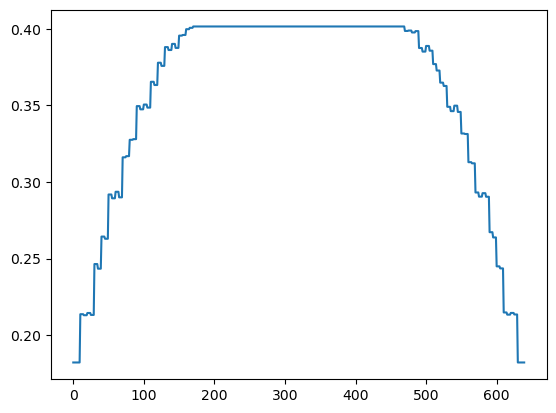

In [ ]:
plt.plot(V_orb_loop_eV)

Recomputed charge density from H_device_biased over E_grid
nE_int=501, workers=111
rho_eq_orb range: [1.0914e-04, 2.9054e-03]
rho_neq_orb range: [0.0000e+00, 0.0000e+00]
rho_plot range (DG0): [2.7628e-03, 5.7429e-03]


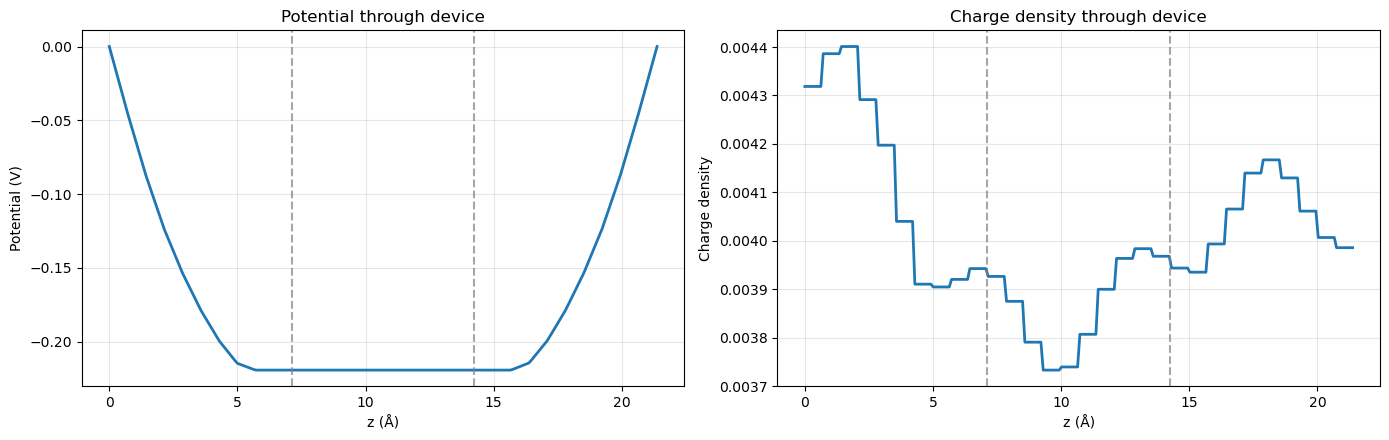

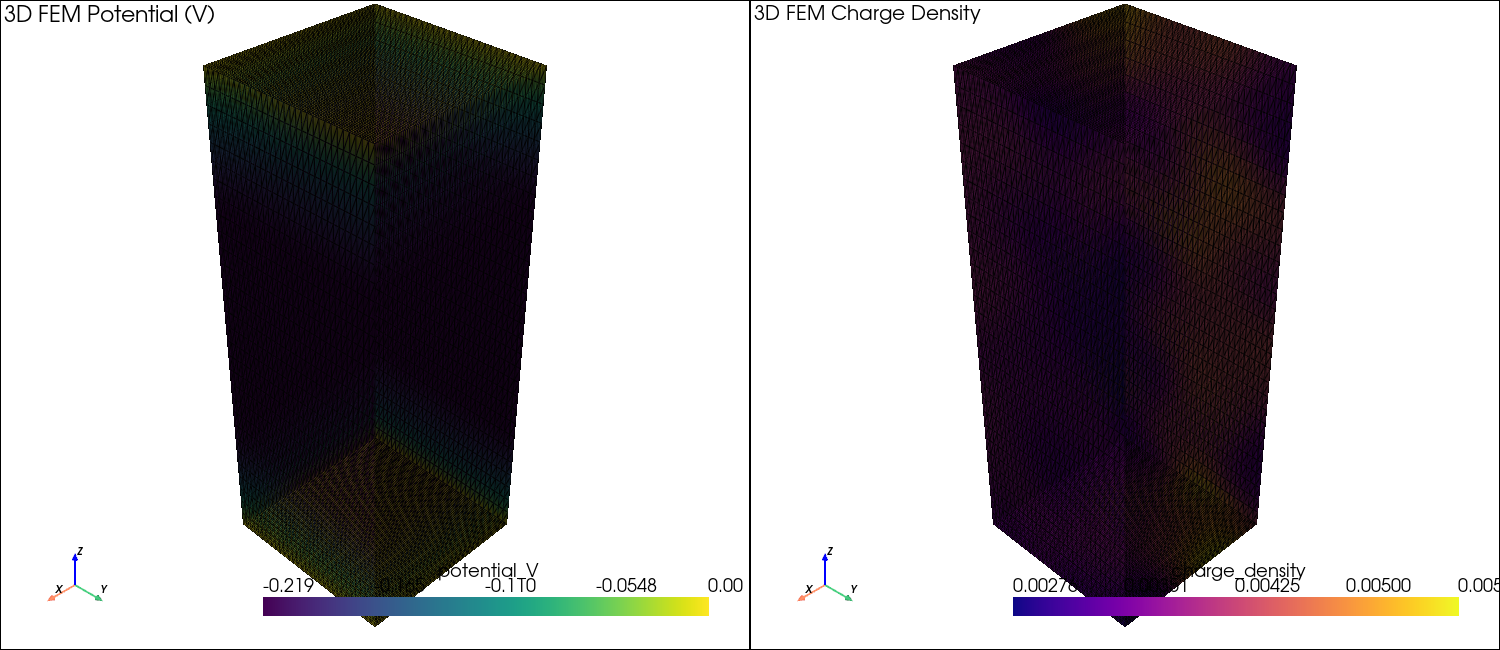

Potential range (V): [-2.1938e-01, 1.4926e-17]
Charge range (DG0): [2.7628e-03, 5.7429e-03]


In [ ]:
# Post-Gummel visualization: recompute charge density from energy integration, then plot
import os
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from dolfinx import plot as dfx_plot
from negf.gf.recursive_greens_functions import _recursive_inverse

phi_plot = phi_gummel

# ----- Recompute charge density from NEGF integration over E_grid -----
if "H_device_biased" not in globals():
    raise RuntimeError("H_device_biased is not defined. Run the Hamiltonian update/Gummel cells first.")
if "sigma_L_cache" not in globals() or "sigma_R_cache" not in globals() or "E_grid" not in globals():
    raise RuntimeError("Energy grid or sigma caches are missing. Run sigma precompute first.")

kbT_eff = float(kbT) if "kbT" in globals() else 0.025851999786435
mu_eq = float(mu_left)

nE_int = min(len(E_grid), len(sigma_L_cache), len(sigma_R_cache))
E_int = np.asarray(E_grid[:nE_int], dtype=float)
dE_int = np.gradient(E_int)

n_orb = H_device_biased.shape[0]
rho_eq_orb = np.zeros(n_orb, dtype=float)
rho_neq_orb = np.zeros(n_orb, dtype=float)


def _fd(E, mu, kT):
    x = np.clip((E - mu) / max(kT, 1e-12), -200.0, 200.0)
    return 1.0 / (1.0 + np.exp(x))


def _charge_contrib_parallel(i):
    E = float(E_int[i])
    sigL = sigma_L_cache[i]
    sigR = sigma_R_cache[i]

    fL = _fd(E, mu_left, kbT_eff)
    fR = _fd(E, mu_right, kbT_eff)
    fEq = _fd(E, mu_eq, kbT_eff)

    out_tot = _recursive_inverse(
        E,
        H_device_biased,
        sigL,
        sigR,
        compute_lesser=True,
        occ_left=fL,
        occ_right=fR,
        overlap_matrix=S_device,
        eta=_eta,
        return_trace=False,
        return_diag=True,
        return_gamma=True,
    )
    out_eq = _recursive_inverse(
        E,
        H_device_biased,
        sigL,
        sigR,
        compute_lesser=True,
        occ_left=fEq,
        occ_right=fEq,
        overlap_matrix=S_device,
        eta=_eta,
        return_trace=False,
        return_diag=True,
        return_gamma=True,
    )

    g_less_tot = np.asarray(out_tot[1])
    g_less_eq = np.asarray(out_eq[1])

    # n(E) = -Im[G<(E)] / (2*pi)
    pref = 1.0 / (2.0 * np.pi)
    nE_tot = -np.imag(g_less_tot) * pref
    nE_eq = -np.imag(g_less_eq) * pref

    return i, nE_eq, (nE_tot - nE_eq)


max_workers = min(max(1, (os.cpu_count() or 1) - 1), nE_int)
try:
    ctx = mp.get_context("fork")
    with ProcessPoolExecutor(max_workers=max_workers, mp_context=ctx) as pool:
        for i, nE_eq, nE_neq in pool.map(
            _charge_contrib_parallel,
            range(nE_int),
            chunksize=max(1, nE_int // max(1, 4 * max_workers)),
        ):
            rho_eq_orb += nE_eq * dE_int[i]
            rho_neq_orb += nE_neq * dE_int[i]
except Exception as exc:
    print(f"Parallel charge integration fallback to serial due to: {exc}")
    for i in range(nE_int):
        _, nE_eq, nE_neq = _charge_contrib_parallel(i)
        rho_eq_orb += nE_eq * dE_int[i]
        rho_neq_orb += nE_neq * dE_int[i]

rho_tot_orb = rho_eq_orb + rho_neq_orb
rho_tot_atom = translator.orbitals_to_atoms(rho_tot_orb)
rho_tot_fem_cells = translator.atom_to_fem(rho_tot_atom)

rho_plot = fem.Function(Q)
rho_plot.name = "rho_tot_recomputed"
rho_plot.x.array[:] = np.asarray(rho_tot_fem_cells[: len(rho_plot.x.array)], dtype=default_scalar_type)

print("Recomputed charge density from H_device_biased over E_grid")
print(f"nE_int={nE_int}, workers={max_workers}")
print(f"rho_eq_orb range: [{rho_eq_orb.min():.4e}, {rho_eq_orb.max():.4e}]")
print(f"rho_neq_orb range: [{rho_neq_orb.min():.4e}, {rho_neq_orb.max():.4e}]")
print(f"rho_plot range (DG0): [{rho_plot.x.array.min():.4e}, {rho_plot.x.array.max():.4e}]")

# ----- 1D centerline profiles along z -----
x_mid, y_mid = x_dim / 2.0, y_dim / 2.0
z_pts = np.linspace(0.0, z_dim, 240)
probe_pts = np.column_stack([
    np.full_like(z_pts, x_mid),
    np.full_like(z_pts, y_mid),
    z_pts,
])

bb = dfx_geom_solver.bb_tree(domain, domain.topology.dim)
cell_cands = dfx_geom_solver.compute_collisions_points(bb, probe_pts)
colliding = dfx_geom_solver.compute_colliding_cells(domain, cell_cands, probe_pts)

pts_ok, cells_ok = [], []
for i in range(len(probe_pts)):
    links = colliding.links(i)
    if len(links) > 0:
        pts_ok.append(probe_pts[i])
        cells_ok.append(links[0])

pts_ok = np.asarray(pts_ok)
z_line = pts_ok[:, 2]
phi_line = phi_plot.eval(pts_ok, cells_ok).flatten() * V_0
rho_line = rho_plot.eval(pts_ok, cells_ok).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(z_line, phi_line, lw=2)
axes[0].axvline(z_source_end, color="gray", ls="--", alpha=0.7)
axes[0].axvline(z_drain_start, color="gray", ls="--", alpha=0.7)
axes[0].set_xlabel("z (Å)")
axes[0].set_ylabel("Potential (V)")
axes[0].set_title("Potential through device")
axes[0].grid(alpha=0.3)

axes[1].plot(z_line, rho_line, lw=2)
axes[1].axvline(z_source_end, color="gray", ls="--", alpha=0.7)
axes[1].axvline(z_drain_start, color="gray", ls="--", alpha=0.7)
axes[1].set_xlabel("z (Å)")
axes[1].set_ylabel("Charge density")
axes[1].set_title("Charge density through device")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ----- 3D FEM views -----
topo, cell_types, geom = dfx_plot.vtk_mesh(domain, domain.topology.dim)
grid3d = pv.UnstructuredGrid(topo, cell_types, geom)

# potential is point-wise (CG1), charge is cell-wise (DG0)
grid3d.point_data["potential_V"] = np.asarray(phi_plot.x.array, dtype=float) * V_0
grid3d.cell_data["charge_density"] = np.asarray(rho_plot.x.array[:grid3d.n_cells], dtype=float)

pl = pv.Plotter(shape=(1, 2), window_size=(1500, 650))
pl.subplot(0, 0)
pl.add_text("3D FEM Potential (V)", font_size=11)
pl.add_mesh(grid3d, scalars="potential_V", cmap="viridis", show_edges=True, opacity=0.95)
pl.add_axes()

pl.subplot(0, 1)
pl.add_text("3D FEM Charge Density", font_size=11)
pl.add_mesh(grid3d, scalars="charge_density", cmap="plasma", show_edges=True, opacity=0.95)
pl.add_axes()

pl.link_views()
pl.show()

print(f"Potential range (V): [{phi_line.min():.4e}, {phi_line.max():.4e}]")
print(f"Charge range (DG0): [{rho_plot.x.array.min():.4e}, {rho_plot.x.array.max():.4e}]")

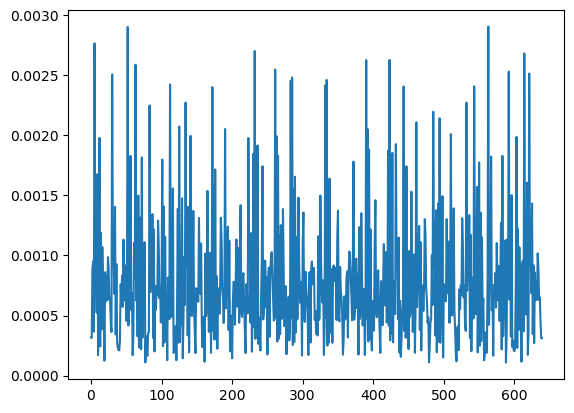

In [ ]:
plt.plot(rho_tot_orb)

--- Translator symmetry diagnostic on rho_tot_orb ---
Orbital profile mirror error: 3.588e-01
Atom profile mirror error:    3.588e-01
FEM line mirror error:        8.621e-02
Charge sum (orbital):         5.070847e-01
Charge sum (atom):            5.070847e-01


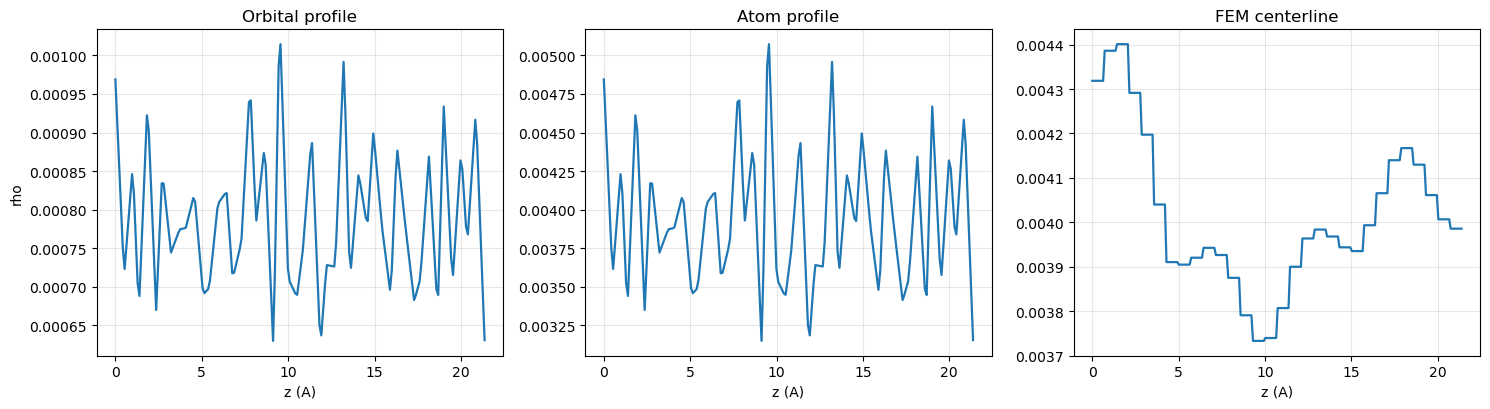

In [ ]:
# Translator diagnostic on rho_tot_orb: compare symmetry through mapping chain
import numpy as np
import matplotlib.pyplot as plt

if "rho_tot_orb" not in globals():
    raise RuntimeError("rho_tot_orb is not defined. Run the charge integration cell first.")
if "translator" not in globals():
    raise RuntimeError("translator is not defined. Run the translator setup cell first.")

# 1) Orbital -> atom
rho_orb = np.asarray(rho_tot_orb, dtype=float)
rho_atom = np.asarray(translator.orbitals_to_atoms(rho_orb), dtype=float)

# Build orbital z coordinates from translator offsets
atom_z = np.asarray(atom_coords_mesh[:, 2], dtype=float)
orb_z = np.zeros_like(rho_orb, dtype=float)
off = np.asarray(translator.offsets, dtype=int)
for a in range(min(len(atom_z), len(off) - 1)):
    orb_z[off[a]:off[a + 1]] = atom_z[a]

# 2) Atom -> FEM (DG0 cell values)
rho_fem_cells = np.asarray(translator.atom_to_fem(rho_atom), dtype=float)

# Helper: mirror-symmetry metric on a profile sampled on z
z0 = float(np.min(atom_z))
z1 = float(np.max(atom_z))

def _sym_err(z, y, n=200):
    z = np.asarray(z, dtype=float)
    y = np.asarray(y, dtype=float)
    order = np.argsort(z)
    z = z[order]
    y = y[order]
    # Collapse duplicate z-values (multiple orbitals per atom)
    z_u, inv = np.unique(z, return_inverse=True)
    y_u = np.zeros_like(z_u, dtype=float)
    c_u = np.zeros_like(z_u, dtype=float)
    np.add.at(y_u, inv, y)
    np.add.at(c_u, inv, 1.0)
    y_u = y_u / np.maximum(c_u, 1.0)

    z_grid = np.linspace(z_u[0], z_u[-1], n)
    y_grid = np.interp(z_grid, z_u, y_u)
    y_mirror = y_grid[::-1]
    denom = max(np.max(np.abs(y_grid)), 1e-20)
    err = np.max(np.abs(y_grid - y_mirror)) / denom
    return z_grid, y_grid, err

# Orbital and atom symmetry
z_orb_g, y_orb_g, err_orb = _sym_err(orb_z, rho_orb)
z_atom_g, y_atom_g, err_atom = _sym_err(atom_z, rho_atom)

# 3) FEM centerline profile symmetry (same path used in your plotting cell)
x_mid, y_mid = x_dim / 2.0, y_dim / 2.0
z_pts = np.linspace(0.0, z_dim, 240)
probe_pts = np.column_stack([
    np.full_like(z_pts, x_mid),
    np.full_like(z_pts, y_mid),
    z_pts,
])

bb = dfx_geom_solver.bb_tree(domain, domain.topology.dim)
cell_cands = dfx_geom_solver.compute_collisions_points(bb, probe_pts)
colliding = dfx_geom_solver.compute_colliding_cells(domain, cell_cands, probe_pts)

pts_ok, cells_ok = [], []
for i in range(len(probe_pts)):
    links = colliding.links(i)
    if len(links) > 0:
        pts_ok.append(probe_pts[i])
        cells_ok.append(links[0])

pts_ok = np.asarray(pts_ok)
z_fem = pts_ok[:, 2]

rho_tmp = fem.Function(Q)
rho_tmp.x.array[:] = np.asarray(rho_fem_cells[: len(rho_tmp.x.array)], dtype=default_scalar_type)
rho_fem_line = rho_tmp.eval(pts_ok, cells_ok).flatten()

_, _, err_fem = _sym_err(z_fem, rho_fem_line)

print("--- Translator symmetry diagnostic on rho_tot_orb ---")
print(f"Orbital profile mirror error: {err_orb:.3e}")
print(f"Atom profile mirror error:    {err_atom:.3e}")
print(f"FEM line mirror error:        {err_fem:.3e}")
print(f"Charge sum (orbital):         {np.sum(rho_orb):.6e}")
print(f"Charge sum (atom):            {np.sum(rho_atom):.6e}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].plot(z_orb_g, y_orb_g, lw=1.6)
ax[0].set_title("Orbital profile")
ax[0].set_xlabel("z (A)")
ax[0].set_ylabel("rho")
ax[0].grid(alpha=0.3)

ax[1].plot(z_atom_g, y_atom_g, lw=1.6)
ax[1].set_title("Atom profile")
ax[1].set_xlabel("z (A)")
ax[1].grid(alpha=0.3)

ax[2].plot(z_fem, rho_fem_line, lw=1.6)
ax[2].set_title("FEM centerline")
ax[2].set_xlabel("z (A)")
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

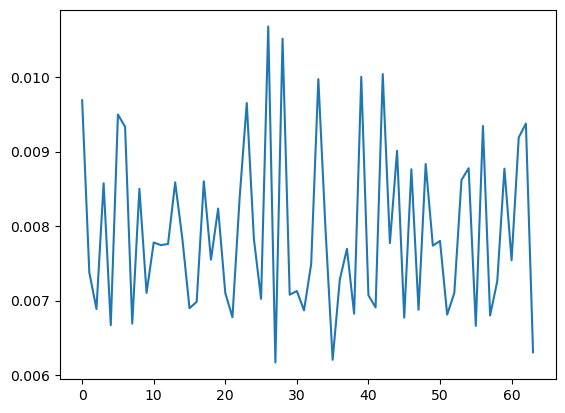

In [ ]:
summed_groups = [sum(rho_tot_orb[i:i + 10]) for i in range(0, len(rho_tot_orb), 10)]
plt.plot(summed_groups)

Current (A): 0.000000e+00
Current (uA): 0.000000e+00
Current density proxy (A/um): 0.000000e+00
Transmission range: [3.367e-13, 1.831e+00]


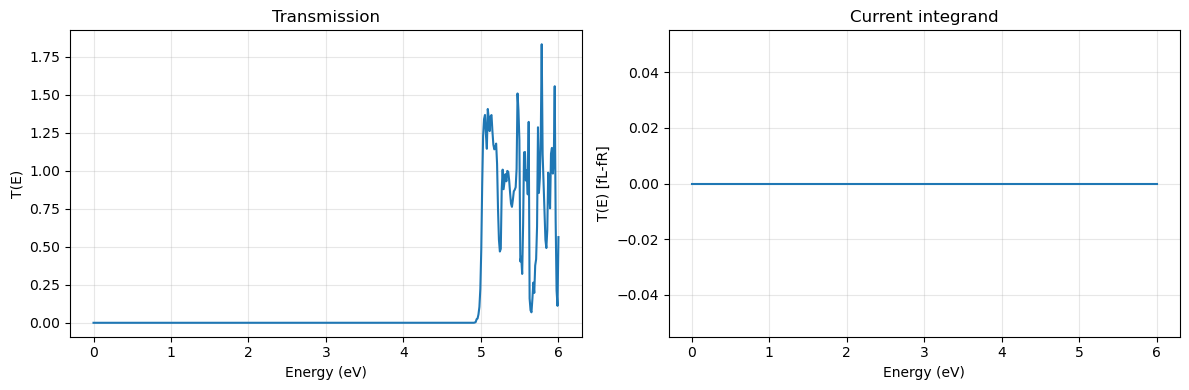

In [ ]:
# Current calculation using full sparse matrix Green's function (no recursive GF for transmission)
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy import constants as spc

# ---- controls ----
current_energy_stride = 1   # >1 for quick debug, 1 for full accuracy
use_phi_gummel_hamiltonian = True

if use_phi_gummel_hamiltonian and "phi_gummel" in globals():
    phi_atom_cur = translator.fem_to_atom(phi_gummel)
    phi_orb_cur = translator.atoms_to_orbitals(phi_atom_cur)
    H_for_current = np.array(H_device, copy=True)
    _diag = np.diag_indices(H_for_current.shape[0])
    H_for_current[_diag] = H_for_current[_diag] - (phi_orb_cur * V_0) - Ef0
else:
    H_for_current = H_device_biased

idx = np.arange(0, len(E_grid), current_energy_stride, dtype=int)
E_cur = np.asarray(E_grid[idx], dtype=float)
dE_cur = np.gradient(E_cur)

def _fd(E, mu, kT):
    x = np.clip((E - mu) / max(kT, 1e-12), -200.0, 200.0)
    return 1.0 / (1.0 + np.exp(x))

n_orb = H_for_current.shape[0]
eta_cur = _eta if "_eta" in globals() else 1e-6

# Static sparse operators
H_sp = sp.csr_matrix(H_for_current.astype(np.complex128))
S_sp = sp.csr_matrix(S_device.astype(np.complex128))
I_dense = np.eye(n_orb, dtype=np.complex128)

T_of_E = np.zeros(len(E_cur), dtype=float)
f_diff = np.zeros(len(E_cur), dtype=float)

for j, ii in enumerate(idx):
    E = float(E_grid[ii])
    sigL_blk = np.asarray(sigma_L_cache[ii], dtype=np.complex128)
    sigR_blk = np.asarray(sigma_R_cache[ii], dtype=np.complex128)

    # Build full sparse operator: A(E) = (E + iη)S - H - ΣL - ΣR
    A_sp = ((E + 1j * eta_cur) * S_sp - H_sp).tolil()
    A_sp[:nL, :nL] -= sigL_blk
    A_sp[-nL:, -nL:] -= sigR_blk
    A_sp = A_sp.tocsc()

    # Full inverse via sparse LU solve against identity
    lu = spla.splu(A_sp)
    G_full = lu.solve(I_dense)

    # Embed full lead self-energies and compute full Γ matrices
    Sigma_L_full = np.zeros((n_orb, n_orb), dtype=np.complex128)
    Sigma_R_full = np.zeros((n_orb, n_orb), dtype=np.complex128)
    Sigma_L_full[:nL, :nL] = sigL_blk
    Sigma_R_full[-nL:, -nL:] = sigR_blk

    Gamma_L_full = 1j * (Sigma_L_full - Sigma_L_full.conj().T)
    Gamma_R_full = 1j * (Sigma_R_full - Sigma_R_full.conj().T)

    # Standard full-matrix transmission expression
    prod = Gamma_L_full @ G_full @ Gamma_R_full @ G_full.conj().T
    T_val = np.real(np.trace(prod))
    T_of_E[j] = max(T_val, 0.0)

    fL = _fd(E, mu_left, kbT if "kbT" in globals() else 0.025851999786435)
    fR = _fd(E, mu_right, kbT if "kbT" in globals() else 0.025851999786435)
    f_diff[j] = fL - fR

# E is in eV, so dE_J = q * dE_eV -> prefactor (2 q^2 / h)
pref = 2.0 * (spc.elementary_charge ** 2) / spc.h
I_amp = pref * np.sum(T_of_E * f_diff * dE_cur)

print(f"Current (A): {I_amp:.6e}")
print(f"Current (uA): {I_amp*1e6:.6e}")
print(f"Current density proxy (A/um): {I_amp/1e6:.6e}")
print(f"Transmission range: [{T_of_E.min():.3e}, {T_of_E.max():.3e}]")

# quick diagnostic plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(E_cur, T_of_E, lw=1.5)
ax[0].set_xlabel("Energy (eV)")
ax[0].set_ylabel("T(E)")
ax[0].set_title("Transmission")
ax[0].grid(alpha=0.3)

ax[1].plot(E_cur, T_of_E * f_diff, lw=1.5)
ax[1].set_xlabel("Energy (eV)")
ax[1].set_ylabel("T(E) [fL-fR]")
ax[1].set_title("Current integrand")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

--- Ec(x) extraction from atom LDOS + IDOS ---
Energy window: [-17.000, 6.000] eV with 401 points
Valid atoms with finite Ec: 128/128
Global Ec from summed LDOS: -2.394323 eV
Median Ec(x): -2.389639 eV
Ec underestimation (global - median Ec(x)): -0.004684 eV


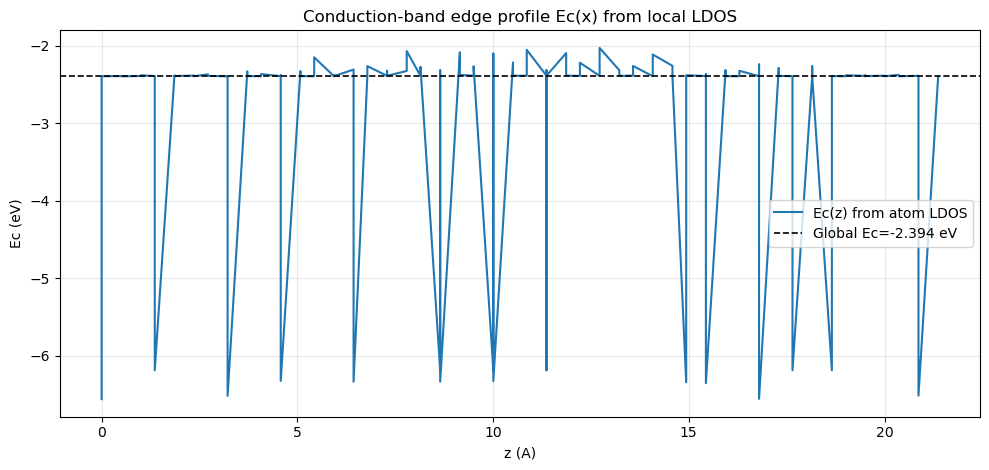

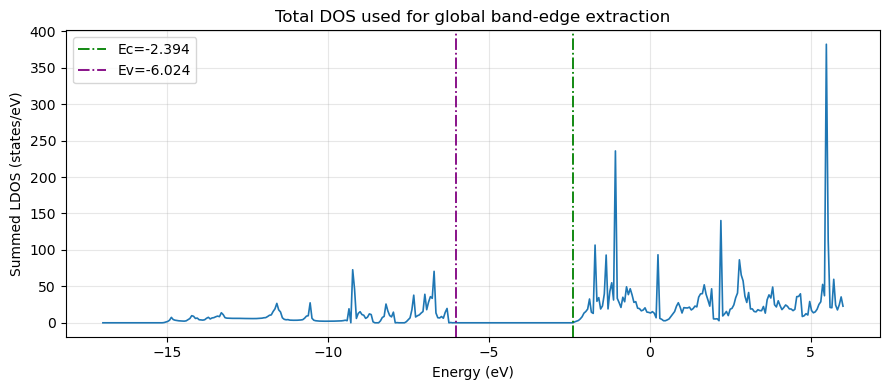

In [ ]:
# Ec(x) from atom-resolved LDOS integrated over energy (IDOS-based edge extraction)
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp
from negf.gf.recursive_greens_functions import _recursive_inverse

# ---------- controls ----------
nE_ecx = 401
eta_ecx = 1e-6
damp_ecx = 1e-9j
tol_ecx = 1e-12
nproc_ecx = 16
show_atom_scatter = False

# Choose Hamiltonian consistent with latest electrostatics
if "H_device_biased" in globals():
    H_for_ecx = np.asarray(H_device_biased, dtype=np.complex128)
else:
    H_for_ecx = np.asarray(H_device, dtype=np.complex128)

# Wide enough window is important; too narrow typically underestimates Ec
E_min = float(min(-17.0, np.min(E_grid))) if "E_grid" in globals() else -17.0
E_max = float(max(2.0, np.max(E_grid))) if "E_grid" in globals() else 2.0
E_ldos = np.linspace(E_min, E_max, nE_ecx)

mu_left_loc = float(mu_left) if "mu_left" in globals() else float(V_applied_left)
mu_right_loc = float(mu_right) if "mu_right" in globals() else float(V_applied_right)

def _find_Ec_Ev_idos(E_grid_loc, dos_loc):
    E_loc = np.asarray(E_grid_loc, dtype=float)
    dos_loc = np.maximum(np.asarray(dos_loc, dtype=float), 0.0)
    n_loc = len(E_loc)

    dE_loc = np.diff(E_loc)
    if np.any(dE_loc <= 0):
        raise ValueError("E grid must be strictly increasing.")

    idos_loc = np.zeros(n_loc, dtype=float)
    idos_loc[1:] = np.cumsum(0.5 * (dos_loc[1:] + dos_loc[:-1]) * dE_loc)

    log_eps = max(1e-18, 1e-12 * float(np.max(dos_loc) + 1e-30))
    log_dos = np.log10(dos_loc + log_eps)
    is_low = log_dos <= np.percentile(log_dos, 30)

    seg = []
    in_seg = False
    s = 0
    for i, f in enumerate(is_low):
        if f and not in_seg:
            s = i
            in_seg = True
        elif (not f) and in_seg:
            seg.append((s, i - 1))
            in_seg = False
    if in_seg:
        seg.append((s, n_loc - 1))

    interior = [
        (a, b)
        for (a, b) in seg
        if a > int(0.03 * n_loc) and b < int(0.97 * n_loc) and a > 0 and b < n_loc - 1
    ]
    if not interior:
        return np.nan, np.nan

    E_mid = 0.5 * (E_loc[0] + E_loc[-1])
    a_gap, b_gap = min(interior, key=lambda t: abs(0.5 * (E_loc[t[0]] + E_loc[t[1]]) - E_mid))
    Ev_coarse = float(E_loc[a_gap - 1])
    Ec_coarse = float(E_loc[b_gap + 1])
    Ef_seed = 0.5 * (Ev_coarse + Ec_coarse)
    I_gap = float(np.median(idos_loc[a_gap:b_gap + 1]))

    def _cross_ev(deltaN):
        idx = np.where(E_loc < Ef_seed)[0]
        if len(idx) < 2:
            return np.nan
        F = (I_gap - idos_loc[idx]) - deltaN
        for k in range(len(idx) - 1, 0, -1):
            f0 = F[k - 1]
            f1 = F[k]
            if f0 * f1 <= 0:
                e0 = E_loc[idx[k - 1]]
                e1 = E_loc[idx[k]]
                if abs(f1 - f0) < 1e-20:
                    return float(e1)
                return float(e0 + (0.0 - f0) * (e1 - e0) / (f1 - f0))
        return np.nan

    def _cross_ec(deltaN):
        idx = np.where(E_loc > Ef_seed)[0]
        if len(idx) < 2:
            return np.nan
        F = (idos_loc[idx] - I_gap) - deltaN
        for k in range(1, len(idx)):
            f0 = F[k - 1]
            f1 = F[k]
            if f0 * f1 <= 0:
                e0 = E_loc[idx[k - 1]]
                e1 = E_loc[idx[k]]
                if abs(f1 - f0) < 1e-20:
                    return float(e0)
                return float(e0 + (0.0 - f0) * (e1 - e0) / (f1 - f0))
        return np.nan

    span = max(float(idos_loc[-1] - idos_loc[0]), 1e-20)
    dN_grid = np.geomspace(1e-6 * span, 2e-3 * span, 25)
    cand = []
    for dN in dN_grid:
        Ev_d = _cross_ev(float(dN))
        Ec_d = _cross_ec(float(dN))
        if np.isfinite(Ev_d) and np.isfinite(Ec_d) and Ec_d > Ev_d:
            cand.append((float(dN), float(Ev_d), float(Ec_d)))

    if len(cand) < 3:
        return Ec_coarse, Ev_coarse

    cand = np.array(cand, dtype=float)
    score = np.full(len(cand), np.inf, dtype=float)
    for i in range(1, len(cand) - 1):
        score[i] = abs(cand[i + 1, 1] - cand[i - 1, 1]) + abs(cand[i + 1, 2] - cand[i - 1, 2])

    ib = int(np.argmin(score))
    return float(cand[ib, 2]), float(cand[ib, 1])

def _sigma_and_ldos_one(args):
    i_loc, E_loc = args
    E_loc = float(E_loc)

    sigL_loc = sancho_rubio_iterative_greens_function(
        E_loc - mu_left_loc,
        h_l=H01_L, h_0=H00_L, h_r=H10_L,
        s_l=S01_L, s_0=S00_L, s_r=S10_L,
        damp=damp_ecx, nconv=tol_ecx,
    )
    sigR_loc = sancho_rubio_iterative_greens_function(
        E_loc - mu_right_loc,
        h_l=H01_R, h_0=H00_R, h_r=H10_R,
        s_l=S01_R, s_0=S00_R, s_r=S10_R,
        damp=damp_ecx, nconv=tol_ecx,
    )

    out = _recursive_inverse(
        E_loc, H_for_ecx, sigL_loc, sigR_loc,
        compute_lesser=False,
        overlap_matrix=S_device,
        eta=eta_ecx,
        return_trace=False,
        return_diag=True,
        return_gamma=False,
    )

    gR_diag = np.asarray(out[0])
    ldos_orb = np.maximum(-np.imag(gR_diag) / np.pi, 0.0)
    return i_loc, ldos_orb

n_orb = H_for_ecx.shape[0]
ldos_orb_E = np.zeros((len(E_ldos), n_orb), dtype=float)

ctx_ecx = mp.get_context("fork")
with ProcessPoolExecutor(max_workers=nproc_ecx, mp_context=ctx_ecx) as ex:
    for i_loc, ldos_orb in ex.map(
        _sigma_and_ldos_one,
        ((i, E_ldos[i]) for i in range(len(E_ldos))),
        chunksize=max(1, len(E_ldos) // (nproc_ecx * 4)),
    ):
        ldos_orb_E[i_loc, :] = ldos_orb

# Aggregate orbital LDOS to atom LDOS at each energy
n_atoms = int(translator.n_atoms)
ldos_atom_E = np.zeros((len(E_ldos), n_atoms), dtype=float)
for i in range(len(E_ldos)):
    ldos_atom_E[i, :] = translator.orbitals_to_atoms(ldos_orb_E[i, :])

# Per-atom Ec from IDOS crossings
Ec_atom = np.full(n_atoms, np.nan, dtype=float)
Ev_atom = np.full(n_atoms, np.nan, dtype=float)
for a in range(n_atoms):
    dos_a = ldos_atom_E[:, a]
    if np.max(dos_a) < 1e-12:
        continue
    Ec_a, Ev_a = _find_Ec_Ev_idos(E_ldos, dos_a)
    Ec_atom[a] = Ec_a
    Ev_atom[a] = Ev_a

# Sort by transport coordinate (z) for Ec(x) profile
z_atom = np.asarray(atom_coords_mesh[:, 2], dtype=float)
order = np.argsort(z_atom)
z_sorted = z_atom[order]
Ec_sorted = Ec_atom[order]
Ev_sorted = Ev_atom[order]

# Compare against global Ec estimate from total DOS
dos_total_ldos = np.sum(ldos_orb_E, axis=1)
Ec_global_idos, Ev_global_idos = _find_Ec_Ev_idos(E_ldos, dos_total_ldos)
Ec_x_median = float(np.nanmedian(Ec_atom))

print("--- Ec(x) extraction from atom LDOS + IDOS ---")
print(f"Energy window: [{E_ldos[0]:.3f}, {E_ldos[-1]:.3f}] eV with {len(E_ldos)} points")
print(f"Valid atoms with finite Ec: {np.count_nonzero(np.isfinite(Ec_atom))}/{n_atoms}")
print(f"Global Ec from summed LDOS: {Ec_global_idos:.6f} eV")
print(f"Median Ec(x): {Ec_x_median:.6f} eV")
print(f"Ec underestimation (global - median Ec(x)): {Ec_global_idos - Ec_x_median:.6f} eV")

plt.figure(figsize=(10, 4.8))
if show_atom_scatter:
    plt.scatter(z_sorted, Ec_sorted, s=10, alpha=0.6, label="Ec per atom")
else:
    plt.plot(z_sorted, Ec_sorted, lw=1.5, label="Ec(z) from atom LDOS")
plt.axhline(Ec_global_idos, color="k", ls="--", lw=1.2, label=f"Global Ec={Ec_global_idos:.3f} eV")
plt.xlabel("z (A)")
plt.ylabel("Ec (eV)")
plt.title("Conduction-band edge profile Ec(x) from local LDOS")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: quick diagnostic of DOS used for global Ec
plt.figure(figsize=(9, 4))
plt.plot(E_ldos, dos_total_ldos, lw=1.2)
plt.axvline(Ec_global_idos, color="green", ls="-.", lw=1.3, label=f"Ec={Ec_global_idos:.3f}")
plt.axvline(Ev_global_idos, color="purple", ls="-.", lw=1.3, label=f"Ev={Ev_global_idos:.3f}")
plt.xlabel("Energy (eV)")
plt.ylabel("Summed LDOS (states/eV)")
plt.title("Total DOS used for global band-edge extraction")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()